In [405]:
import wandb
import pandas as pd
from tqdm import tqdm
import numpy as np

def get_dataframe_from_records(records, add_custom_columns=None):
    """Convert records to a DataFrame."""
    
    # Create DataFrame
    df = pd.DataFrame(records)

    if add_custom_columns:
        df = add_custom_columns(df)

    # Group by group and calculate mean and std
    agg_df = df.groupby("group").agg(['mean', 'std'])
    # chech that for each group there are 5 entries

    agg_df_check = df.groupby("group").count()
    if (agg_df_check < 5).any().any():
        print("Warning: Some groups have fewer than 5 entries.")

    # format to mean /pm std
    # Format as 'mean ± std' rounded to 3 decimals
    formatted_df = agg_df.copy()
    for metric in df.columns[1:]:  # Skip 'group' column
        mean_col = (metric, 'mean')
        std_col = (metric, 'std')
        formatted_col_name = f"{metric} (mean ± std)"
        
        #set min value to row[std_col] to 0.001

        formatted_df[formatted_col_name] = agg_df.apply(
            lambda row: f"{row[mean_col]:.3f} ± {row[std_col]:.3f}", axis=1
        )
    # Optional: flatten the column names
    # agg_df.columns = ['_'.join(col) for col in agg_df.columns]
    # remove original colums
    formatted_df = formatted_df.drop(columns=[(col, 'mean') for col in df.columns[1:]] + [(col, 'std') for col in df.columns[1:]])
    return formatted_df

def only_best(run):
    return run.group is not None and run.group.startswith("best_")

def get_records(project, metrics=[], history=[], pattern=only_best, verbose=False):
    # Authenticate (you must be logged in via wandb.login())
    api = wandb.Api()

    # Replace with your entity/project
    entity = "ecg_ml"

    # Fetch all runs
    runs = api.runs(f"{entity}/{project}")

    # Collect relevant info
    records = []
    for run in tqdm(runs):
        if run.state != "finished":
            continue

        # add only if group name starts with best_
        if not pattern(run):
            continue

        # Get the group name
        group = run.group or "ungrouped"

        record = {
            "group": group
        }

        # Extract your test metrics — replace with your actual metric names
        if verbose:
            print(f"Processing run {run.id} in group '{group}'")
            # print metrics of the run
            print("Metrics:", [key for key in run.summary.keys() if key.startswith("test_")])

        for metric in metrics:
            if metric not in run.summary:
                print(f"Warning: Metric '{metric}' not found in run {run.id}.")
                continue
            record[metric] = run.summary.get(metric)

        for metric, mode in history:
            if metric not in run.history(keys=[metric]).columns:
                print(f"Warning: Metric '{metric}' not found in history of run {run.id}.")
                continue
            if mode == 'max':
                record[metric] = run.history(keys=[metric])[metric].dropna().max()
            elif mode == 'min':
                record[metric] = run.history(keys=[metric])[metric].dropna().min()
            else:
                record[metric] = run.history(keys=[metric])[metric].dropna().values[-1]

        records.append(record)
    return records

def style_mean_column(col):
    # Extract float values from the strings
    mean_vals = col.str.extract(r"^([\d.]+)")[0].astype(float)
    
    # Get indices of highest and second highest
    top2_idx = mean_vals.nlargest(2).index

    # Build styles
    styles = []
    for i in col.index:
        if i == top2_idx[0]:
            styles.append("font-weight: bold")
        elif i == top2_idx[1]:
            styles.append("text-decoration: underline")
        else:
            styles.append("")
    return styles

def style_mean_column_min(col):
    # Extract float values from the strings
    mean_vals = col.str.extract(r"^([\d.]+)")[0].astype(float)
    
    # Get indices of highest and second highest
    # Get indices of smallest and second smallest
    top2_idx = mean_vals.nsmallest(2).index

    # Build styles
    styles = []
    for i in col.index:
        if i == top2_idx[0]:
            styles.append("font-weight: bold")
        elif i == top2_idx[1]:
            styles.append("text-decoration: underline")
        else:
            styles.append("")
    return styles

rename_map = {
    "best_stmem_ft": "ST-MEM",
    "best_stmem_lp": "ST-MEM",
    "best_jepa_ft": "ECG-JEPA",
    "best_jepa_lp": "ECG-JEPA",
    "best_ecgfm_ft": "ECGFounder",
    "best_ecgfm_lp": "ECGFounder",
    "best_trans_ft": r"\textbf{ours (transformer)}",
    "best_trans_lp": r"\textbf{ours (transformer)}",
    "best_xlstm_ft": r"\textbf{ours (xlstm)}",
    "best_xlstm_lp": r"\textbf{ours (xlstm)}",
    "best_xlstm_sup": r"\textbf{ours (xlstm)}"
}

rename_map_2= {
    "best_stmem_ft": "ST-MEM (FT)",
    "best_stmem_lp": "ST-MEM (LP)",
    "best_jepa_ft": "ECG-JEPA (FT)",
    "best_jepa_lp": "ECG-JEPA (LP)",
    "best_ecgfm_ft": "ECGFounder (FT)",
    "best_ecgfm_lp": "ECGFounder (LP)",
    "best_trans_ft": "Transformer (FT)",
    "best_trans_lp": "Transformer (LP)",
    "best_xlstm_ft": "Ours (FT)",
    "best_xlstm_lp": "Ours (LP)",
    "best_xlstm_sup": "Ours (Sup)"
}

rename_map_3 = {
    "best_stmem_ft": "ST-MEM",
    "best_stmem_lp": "ST-MEM",
    "best_jepa_ft": "ECG-JEPA",
    "best_jepa_lp": "ECG-JEPA",
    "best_ecgfm_ft": "ECGFounder",
    "best_ecgfm_lp": "ECGFounder",
    "best_trans_ft": "SimDINOv2Transformer",
    "best_trans_lp": "SimDINOv2 Transformer",
    "best_xlstm_ft": "xECG",
    "best_xlstm_lp": "xECG",
    "best_xlstm_sup": "Supervised xLSTM"
}

colors_idxs = {
    "best_stmem_ft": "#636EFAC0",
    "best_stmem_lp": "#636EFAC0",
    "best_jepa_ft": "#EF553BC0",
    "best_jepa_lp": "#EF553BC0",
    "best_ecgfm_ft": "#00CC96C0",
    "best_ecgfm_lp": "#00CC96C0",
    "best_trans_ft": "#AB63FAC0",
    "best_trans_lp": "#AB63FAC0",
    "best_xlstm_ft": "#FFA15AC0",
    "best_xlstm_lp": "#FFA15AC0",
    "best_xlstm_sup": "#19D3F3C0"
}


In [378]:
def apply_style(df):
    # Apply styles to the DataFrame
    df['_runtime'] = df['_runtime'] / (60 * 60)
    return df.style.apply(style_mean_column)

def apply_highlight(df, order, metrics, method='min'):
    """Bold = max, Underline = second max"""
    df = df.loc[order].copy()
    for col, _ in metrics:
        values = df[col].str.split("±").str[0].astype(float)
        ranking = values.rank(method=method, ascending=False)  # 1 = max, 2 = second max
        formatted = []
        for val, rank in zip(df[col], ranking):
            if rank == 1:
                formatted.append(r"\textbf{" + val.strip() + "}")
            elif rank == 2:
                formatted.append(r"\underline{" + val.strip() + "}")
            else:
                formatted.append(val.strip())
        df[col] = formatted
    return df

def row_to_latex(name, row, rename_map, metrics):
    return f"{rename_map[name]} & " + " & ".join([row[col].values[0] for col, _ in metrics]) + r" \\"

order_lp = ["best_stmem_lp", "best_jepa_lp", "best_ecgfm_lp", "best_trans_lp", "best_xlstm_lp"]
order_ft = ["best_stmem_ft", "best_jepa_ft", "best_ecgfm_ft", "best_trans_ft", "best_xlstm_ft"]


In [358]:
ft_groups = ['best_ecgfm_ft', 'best_jepa_ft', 'best_stmem_ft', 'best_trans_ft', 'best_xlstm_ft', 'best_xlstm_sup']
lp_groups = ['best_ecgfm_lp', 'best_jepa_lp', 'best_stmem_lp', 'best_trans_lp', 'best_xlstm_lp']

# PTB-XL metrics

In [ ]:
metrics = ["test_acc", "test_f1", "test_auroc", "test_auprc", '_runtime']
records_ptb_xl = get_records("train-ptbxl-diagnosis_superclass-multilabel", metrics=metrics)

formatted_df = get_dataframe_from_records(records_ptb_xl)

## Finetuning

In [6]:
# ands with _ft or _sup
ptbxl_ft = formatted_df[formatted_df.index.isin(ft_groups)]
styled_df = ptbxl_ft.style.apply(style_mean_column)
styled_df

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_ft,0.891 ± 0.001,0.734 ± 0.002,0.930 ± 0.001,0.822 ± 0.001,805.316 ± 8.746
best_jepa_ft,0.884 ± 0.001,0.733 ± 0.003,0.923 ± 0.001,0.809 ± 0.001,5650.440 ± 26.342
best_stmem_ft,0.892 ± 0.001,0.739 ± 0.005,0.930 ± 0.001,0.822 ± 0.002,3879.754 ± 15.904
best_trans_ft,0.880 ± 0.002,0.710 ± 0.017,0.925 ± 0.001,0.808 ± 0.001,323.377 ± 16.639
best_xlstm_ft,0.884 ± 0.002,0.718 ± 0.011,0.928 ± 0.001,0.816 ± 0.003,483.656 ± 12.877
best_xlstm_sup,0.860 ± 0.005,0.667 ± 0.007,0.891 ± 0.004,0.748 ± 0.006,499.091 ± 15.265


## Linear probing

In [360]:
ptbxl_lp = formatted_df[formatted_df.index.str.endswith("_lp")]
styled_df_lp = ptbxl_lp.style.apply(style_mean_column)
styled_df_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp,0.883 ± 0.001,0.702 ± 0.002,0.917 ± 0.001,0.799 ± 0.001,377.904 ± 4.972
best_jepa_lp,0.864 ± 0.001,0.712 ± 0.002,0.902 ± 0.001,0.769 ± 0.001,2091.479 ± 4.906
best_stmem_lp,0.847 ± 0.001,0.564 ± 0.002,0.867 ± 0.001,0.693 ± 0.001,1493.105 ± 2.861
best_trans_lp,0.875 ± 0.001,0.703 ± 0.002,0.914 ± 0.001,0.782 ± 0.001,228.304 ± 4.401
best_xlstm_lp,0.876 ± 0.001,0.690 ± 0.001,0.915 ± 0.001,0.788 ± 0.001,322.295 ± 6.590


## Linear probing 10%

In [8]:
agg_df_10 = formatted_df[formatted_df.index.str.endswith("_10")]
styled_df_10 = agg_df_10.style.apply(style_mean_column)
styled_df_10

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp_10,0.868 ± 0.001,0.616 ± 0.006,0.891 ± 0.001,0.745 ± 0.004,219.112 ± 32.960
best_jepa_lp_10,0.789 ± 0.003,0.638 ± 0.003,0.878 ± 0.002,0.711 ± 0.011,522.137 ± 8.870
best_stmem_lp_10,0.808 ± 0.001,0.314 ± 0.015,0.816 ± 0.002,0.565 ± 0.007,423.572 ± 3.300
best_trans_lp_10,0.862 ± 0.001,0.663 ± 0.004,0.893 ± 0.001,0.741 ± 0.002,162.728 ± 19.854
best_xlstm_lp_10,0.859 ± 0.002,0.613 ± 0.002,0.884 ± 0.002,0.718 ± 0.010,164.256 ± 5.382


## Linear probing 1%

In [9]:
agg_df_1 = formatted_df[formatted_df.index.str.endswith("_1")]
styled_df_1 = agg_df_1.style.apply(style_mean_column)
styled_df_1

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp_1,0.849 ± 0.005,0.623 ± 0.012,0.864 ± 0.007,0.678 ± 0.019,155.753 ± 22.135
best_jepa_lp_1,0.722 ± 0.012,0.571 ± 0.010,0.825 ± 0.008,0.615 ± 0.018,292.139 ± 34.668
best_stmem_lp_1,0.799 ± 0.003,0.343 ± 0.014,0.769 ± 0.004,0.506 ± 0.009,306.723 ± 3.040
best_trans_lp_1,0.749 ± 0.015,0.595 ± 0.009,0.841 ± 0.006,0.633 ± 0.010,88.689 ± 5.228
best_xlstm_lp_1,0.827 ± 0.007,0.526 ± 0.042,0.836 ± 0.008,0.621 ± 0.009,155.339 ± 37.376


# CPSC 2018

In [10]:
records_cpsc = get_records("train-cpsc2018-multilabel", metrics=["test_acc", "test_f1", "test_auroc", "test_auprc", '_runtime'])
formatted_df_cpsc = get_dataframe_from_records(records_cpsc)

100%|██████████| 307/307 [00:42<00:00,  7.19it/s]


## Finetuning

In [11]:
cpsc_ft = formatted_df_cpsc[formatted_df_cpsc.index.isin(ft_groups)]

styled_df_ft = cpsc_ft.style.apply(style_mean_column)
styled_df_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_ft,0.964 ± 0.001,0.794 ± 0.005,0.969 ± 0.001,0.854 ± 0.002,406.169 ± 10.301
best_jepa_ft,0.942 ± 0.003,0.749 ± 0.009,0.965 ± 0.001,0.842 ± 0.003,1705.833 ± 44.027
best_stmem_ft,0.963 ± 0.001,0.789 ± 0.012,0.958 ± 0.003,0.835 ± 0.011,1314.123 ± 14.290
best_trans_ft,0.961 ± 0.001,0.796 ± 0.008,0.965 ± 0.003,0.853 ± 0.006,212.527 ± 12.297
best_xlstm_ft,0.968 ± 0.001,0.822 ± 0.008,0.981 ± 0.001,0.888 ± 0.003,731.973 ± 30.716
best_xlstm_sup,0.952 ± 0.001,0.719 ± 0.008,0.951 ± 0.002,0.813 ± 0.006,846.747 ± 71.359


## Linear probing

In [12]:
formatted_df_cpsc_lp = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_lp")]
styled_df_lp = formatted_df_cpsc_lp.style.apply(style_mean_column)
styled_df_lp


,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp,0.958 ± 0.001,0.750 ± 0.007,0.962 ± 0.001,0.830 ± 0.001,252.192 ± 4.276
best_jepa_lp,0.889 ± 0.002,0.613 ± 0.003,0.961 ± 0.001,0.830 ± 0.001,746.866 ± 3.697
best_stmem_lp,0.935 ± 0.001,0.455 ± 0.005,0.922 ± 0.001,0.722 ± 0.004,604.956 ± 2.832
best_trans_lp,0.953 ± 0.001,0.733 ± 0.008,0.951 ± 0.001,0.787 ± 0.008,248.633 ± 32.202
best_xlstm_lp,0.961 ± 0.002,0.781 ± 0.011,0.968 ± 0.001,0.861 ± 0.004,461.689 ± 6.262


## Linear probing 10%


In [13]:
formatted_df_cpsc_10 = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_10")]
styled_df_cpsc_10 = formatted_df_cpsc_10.style.apply(style_mean_column)
styled_df_cpsc_10

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp_10,0.913 ± 0.002,0.182 ± 0.011,0.919 ± 0.003,0.672 ± 0.012,197.652 ± 3.593
best_jepa_lp_10,0.748 ± 0.004,0.451 ± 0.003,0.934 ± 0.007,0.763 ± 0.013,316.687 ± 3.869
best_stmem_lp_10,0.885 ± 0.003,0.027 ± 0.016,0.798 ± 0.010,0.448 ± 0.005,294.200 ± 5.431
best_trans_lp_10,0.789 ± 0.013,0.461 ± 0.011,0.898 ± 0.006,0.653 ± 0.012,151.518 ± 10.365
best_xlstm_lp_10,0.930 ± 0.002,0.406 ± 0.025,0.913 ± 0.007,0.689 ± 0.027,237.764 ± 5.794


## Linear probing 1%

In [14]:
formatted_df_cpsc_1 = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_1")]
styled_df_cpsc_1 = formatted_df_cpsc_1.style.apply(style_mean_column)
styled_df_cpsc_1

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_ecgfm_lp_1,0.933 ± 0.005,0.481 ± 0.073,0.920 ± 0.007,0.678 ± 0.012,141.167 ± 17.314
best_jepa_lp_1,0.674 ± 0.007,0.384 ± 0.007,0.878 ± 0.010,0.598 ± 0.020,141.575 ± 20.931
best_stmem_lp_1,0.908 ± 0.006,0.250 ± 0.043,0.827 ± 0.012,0.479 ± 0.024,226.514 ± 3.257
best_trans_lp_1,0.714 ± 0.021,0.389 ± 0.017,0.827 ± 0.013,0.515 ± 0.011,64.556 ± 7.530
best_xlstm_lp_1,0.915 ± 0.010,0.401 ± 0.086,0.873 ± 0.015,0.591 ± 0.029,174.486 ± 7.431


In [480]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

def df_to_latex_table(ptb_xl_records, cpsc_records, name_map):
    ptb_xl_df = pd.DataFrame(ptb_xl_records).set_index("group")
    cpsc_df = pd.DataFrame(cpsc_records).set_index("group")

    metrics = [
        ("test_acc", "ACC"),
        ("test_f1", "F1"),
        ("test_auroc", "AUROC"),
        ("test_auprc", "AUPRC"),
    ]

    def highlight_groups(df, metric):
        groups = df.index.unique()
        means = df.groupby(level=0)[metric].mean()
        stds = df.groupby(level=0)[metric].std()

        # pairwise t-tests
        pvals = pd.DataFrame(index=groups, columns=groups, dtype=float)
        for g1 in groups:
            for g2 in groups:
                if g1 == g2:
                    pvals.loc[g1, g2] = 1.0
                else:
                    s1 = df.loc[g1, metric]
                    s2 = df.loc[g2, metric]
                    _, p = ttest_ind(s1, s2, equal_var=False)
                    pvals.loc[g1, g2] = p

        best_mean = means.max()
        best_idx = means.idxmax()
        best_groups = [means.idxmax()]

            
        bold = []
        for g in groups:
            # print(best_groups)
            # print(f'Checking {g} against best_groups: {best_groups}, the check is: {[pvals.loc[g, b] > 0.05 for b in best_groups]}')
            if all(pvals.loc[g, b] > 0.05 for b in best_groups):
                # print(f'Adding {g} to bold')
                bold.append(g)

        underline = []
        if len(bold) == 1:
            sorted_groups = means.sort_values(ascending=False)
            for g in sorted_groups.index:
                if g != bold[0] and pvals.loc[g, bold[0]] > 0.05:
                    underline.append(g)
                    break
            if underline == []:
                underline.append(sorted_groups.index[1])

        return bold, underline

    def format_val(group, mean, std, bold, underline):
        val = f"{mean:.3f} $\\pm$ {std:.3f}"
        if group in bold:
            val = f"\\textbf{{{val}}}"
        elif group in underline:
            val = f"\\underline{{{val}}}"
        return val

    def row_to_latex(name, df1, df2, rename_map, metrics, highlights1=None, highlights2=None):
        if highlights1:
            bold1 = [h[0] for h in highlights1]
            underline1 = [h[1] for h in highlights1]
        else:
            bold1 = [[] for _ in metrics]
            underline1 = [[] for _ in metrics]
        if highlights2:
            bold2 = [h[0] for h in highlights2]
            underline2 = [h[1] for h in highlights2]
        else:
            bold2 = [[] for _ in metrics]
            underline2 = [[] for _ in metrics]

        row = [rename_map[name], ""]
        row += [format_val(name, df1[col].mean(), df1[col].std(), bold1[i], underline1[i]) for i, (col, _) in enumerate(metrics)]
        row += [format_val(name, df2[col].mean(), df2[col].std(), bold2[i], underline2[i]) for i, (col, _) in enumerate(metrics)]
        return r"   " + " & ".join(row) + r" \\"

    latex = []
    latex.append(r"\begin{table*}[h!]")
    latex.append(r"\resizebox{\textwidth}{!}{")
    latex.append(r"    \begin{tabular}{ll|cccc|cccc}")
    latex.append(r"    \toprule")
    latex.append(r"    \multirow{2}{*}{\textbf{Methods}} & \multirow{2}{*}{} & \multicolumn{4}{c|}{\textbf{PTB-XL}} & \multicolumn{4}{c}{\textbf{CPSC2018}} \\")
    latex.append(r"     & & Accuracy & F1 & AUROC & AUPRC & Accuracy & F1 & AUROC & AUPRC \\")
    latex.append(r"    \midrule")

    # supervised
    latex.append(r"    \multicolumn{10}{c}{\textbf{Supervised}} \\")
    latex.append(r"    \midrule")
    latex.append(r"     xLSTM-ECG \cite{kang2025xlstm} &&  0.875 & - & 0.913 & - & - & - & - & \\")
    latex.append(r"     ASTLNet \cite{10080902}  &&  0.629 & - & 0.913 & - & - & - & - & \\")
    latex.append(r"     ECGNet \cite{8438739} &&  0.873 & - & 0.901 & - & - & - & - & \\")

    sup_name = "best_xlstm_sup"
    row1 = ptb_xl_df.loc[sup_name]
    row2 = cpsc_df.loc[sup_name]

    latex.append(row_to_latex(sup_name, row1, row2, name_map, metrics))

    latex.append(r"    \midrule")
    latex.append(r"    \multicolumn{10}{c}{\textbf{Linear Probing}} \\")
    latex.append(r"    \midrule")

    ptb_xl_lp = ptb_xl_df[ptb_xl_df.index.isin(lp_groups)] 
    cpsc_lp = cpsc_df[cpsc_df.index.isin(lp_groups)]


    highlights_ptb = [highlight_groups(ptb_xl_lp, m[0]) for m in metrics]
    highlights_cpsc = [highlight_groups(cpsc_lp, m[0]) for m in metrics]
    for name in order_lp:
        latex.append(row_to_latex(name, ptb_xl_lp.loc[name], cpsc_lp.loc[name], name_map, metrics, highlights_ptb, highlights_cpsc))

    latex.append(r"    \midrule")
    latex.append(r"    \multicolumn{10}{c}{\textbf{Finetuning}} \\")
    latex.append(r"    \midrule")

    ptb_xl_ft = ptb_xl_df[ptb_xl_df.index.isin(ft_groups)] 
    cpsc_ft = cpsc_df[cpsc_df.index.isin(ft_groups)]

    highlights_ptb = [highlight_groups(ptb_xl_ft, m[0]) for m in metrics]
    highlights_cpsc = [highlight_groups(cpsc_ft, m[0]) for m in metrics]
    for name in order_ft:
        latex.append(row_to_latex(name, ptb_xl_ft.loc[name], cpsc_ft.loc[name], name_map, metrics, highlights_ptb, highlights_cpsc))

    latex.append(r"    \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(r"}")
    latex.append(r"\caption{Performance comparison on multilabel task PTB-XL and CPSC2018 datasets under linear evaluation and fine-tuning on a multi-label setting.}")
    latex.append(r"\label{tab:ptbxl_multilabel}")
    latex.append(r"\end{table*}")

    return "\n".join(latex)

print(df_to_latex_table(records_ptb_xl, records_cpsc, rename_map_3))

\begin{table*}[h!]
\resizebox{\textwidth}{!}{
    \begin{tabular}{ll|cccc|cccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multirow{2}{*}{} & \multicolumn{4}{c|}{\textbf{PTB-XL}} & \multicolumn{4}{c}{\textbf{CPSC2018}} \\
     & & Accuracy & F1 & AUROC & AUPRC & Accuracy & F1 & AUROC & AUPRC \\
    \midrule
    \multicolumn{10}{c}{\textbf{Supervised}} \\
    \midrule
     xLSTM-ECG \cite{kang2025xlstm} &&  0.875 & - & 0.913 & - & - & - & - & \\
     ASTLNet \cite{10080902}  &&  0.629 & - & 0.913 & - & - & - & - & \\
     ECGNet \cite{8438739} &&  0.873 & - & 0.901 & - & - & - & - & \\
   Supervised xLSTM &  & 0.860 $\pm$ 0.005 & 0.667 $\pm$ 0.007 & 0.891 $\pm$ 0.004 & 0.748 $\pm$ 0.006 & 0.952 $\pm$ 0.001 & 0.719 $\pm$ 0.008 & 0.951 $\pm$ 0.002 & 0.813 $\pm$ 0.006 \\
    \midrule
    \multicolumn{10}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM &  & 0.847 $\pm$ 0.001 & 0.564 $\pm$ 0.002 & 0.867 $\pm$ 0.001 & 0.693 $\pm$ 0.001 & 0.935 $\pm$ 0.000 & 0.455 $\pm$ 0.005 

# MIT-BIH classification

In [15]:
records_mit_cls = get_records("train-mitbih-5", metrics=["test_acc", "test_sensitivity/mean", "test_ppv/mean", "test_specificity/mean", "test_f1/mean", '_runtime'])
formatted_df_mit_cls = get_dataframe_from_records(records_mit_cls)

100%|██████████| 279/279 [00:41<00:00,  6.70it/s]


## Finetuning

In [16]:
mit_ft = formatted_df_mit_cls[formatted_df_mit_cls.index.isin(ft_groups)]

styled_df_mit_ft = mit_ft.style.apply(style_mean_column)
styled_df_mit_ft

,test_acc (mean ± std),test_sensitivity/mean (mean ± std),test_ppv/mean (mean ± std),test_specificity/mean (mean ± std),test_f1/mean (mean ± std),_runtime (mean ± std)
,,,,,,
group,,,,,,
best_ecgfm_ft,0.863 ± 0.008,0.211 ± 0.002,0.207 ± 0.002,0.809 ± 0.002,0.207 ± 0.002,328.807 ± 9.122
best_jepa_ft,0.954 ± 0.001,0.557 ± 0.006,0.629 ± 0.007,0.951 ± 0.001,0.583 ± 0.007,2252.044 ± 15.465
best_stmem_ft,0.967 ± 0.002,0.625 ± 0.007,0.671 ± 0.013,0.965 ± 0.003,0.644 ± 0.007,1783.386 ± 26.314
best_trans_ft,0.896 ± 0.008,0.475 ± 0.002,0.457 ± 0.005,0.905 ± 0.001,0.425 ± 0.006,216.098 ± 25.243
best_xlstm_ft,0.976 ± 0.007,0.651 ± 0.035,0.721 ± 0.019,0.973 ± 0.010,0.677 ± 0.025,708.598 ± 34.795
best_xlstm_sup,0.896 ± 0.013,0.448 ± 0.028,0.416 ± 0.020,0.910 ± 0.004,0.402 ± 0.014,748.898 ± 4.569


## Linear probing

In [17]:
formatted_mit_lp = formatted_df_mit_cls[formatted_df_mit_cls.index.str.endswith("_lp")]
styled_df_mit_lp = formatted_mit_lp.style.apply(style_mean_column)
styled_df_mit_lp


,test_acc (mean ± std),test_sensitivity/mean (mean ± std),test_ppv/mean (mean ± std),test_specificity/mean (mean ± std),test_f1/mean (mean ± std),_runtime (mean ± std)
,,,,,,
group,,,,,,
best_ecgfm_lp,0.865 ± 0.012,0.210 ± 0.004,0.209 ± 0.004,0.808 ± 0.003,0.206 ± 0.005,324.685 ± 14.280
best_jepa_lp,0.946 ± 0.001,0.470 ± 0.003,0.574 ± 0.003,0.933 ± 0.001,0.496 ± 0.003,891.782 ± 8.916
best_stmem_lp,0.937 ± 0.003,0.424 ± 0.027,0.507 ± 0.035,0.920 ± 0.003,0.436 ± 0.036,847.626 ± 47.748
best_trans_lp,0.931 ± 0.001,0.381 ± 0.004,0.549 ± 0.012,0.924 ± 0.004,0.395 ± 0.005,108.508 ± 2.805
best_xlstm_lp,0.972 ± 0.002,0.686 ± 0.021,0.669 ± 0.014,0.976 ± 0.003,0.674 ± 0.013,326.174 ± 3.404


# MIT-BIH r-peaks

In [18]:
records_mit_r_peaks = get_records("train-mitbih-r_peaks", metrics=["test_f1_150", "test_f1_20", "test_avg_total_distance", '_runtime'])
formatted_df_mit_r_peaks = get_dataframe_from_records(records_mit_r_peaks)

100%|██████████| 133/133 [00:14<00:00,  9.43it/s]


## Fine-tuning

In [19]:
mit_r_peaks_ft = formatted_df_mit_r_peaks[formatted_df_mit_r_peaks.index.isin(ft_groups)]
# add sup rows to ft
styled_df_mit_r_peaks_ft = mit_r_peaks_ft.style.apply(style_mean_column)
styled_df_mit_r_peaks_ft

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.081 ± 0.006,0.011 ± 0.001,3794.272 ± 789.848,309.131 ± 14.947
best_jepa_ft,0.996 ± 0.001,0.909 ± 0.004,4.195 ± 0.059,1364.272 ± 16.953
best_stmem_ft,0.994 ± 0.001,0.937 ± 0.001,5.148 ± 0.403,1102.879 ± 9.398
best_trans_ft,0.983 ± 0.001,0.900 ± 0.001,7.587 ± 0.159,278.538 ± 11.780
best_xlstm_ft,0.995 ± 0.001,0.921 ± 0.001,5.208 ± 0.098,223.998 ± 15.288
best_xlstm_sup,0.980 ± 0.007,0.889 ± 0.012,8.217 ± 1.056,191.553 ± 22.564


## Linear probing

In [20]:
formatted_df_mit_r_peaks_lp = formatted_df_mit_r_peaks[formatted_df_mit_r_peaks.index.str.endswith("_lp")]
styled_df_mit_r_peaks_lp = formatted_df_mit_r_peaks_lp.style.apply(style_mean_column)
styled_df_mit_r_peaks_lp

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.073 ± 0.005,0.010 ± 0.001,4564.209 ± 630.534,309.113 ± 5.623
best_jepa_lp,0.976 ± 0.001,0.444 ± 0.001,6.858 ± 0.016,602.930 ± 14.573
best_stmem_lp,0.970 ± 0.001,0.564 ± 0.002,7.430 ± 0.139,502.377 ± 19.211
best_trans_lp,0.864 ± 0.001,0.476 ± 0.001,32.177 ± 0.086,150.891 ± 4.207
best_xlstm_lp,0.945 ± 0.005,0.590 ± 0.011,11.487 ± 0.283,143.034 ± 18.259


# Exercise high intensity r peaks

In [21]:
records_exe_r = get_records("train-exercise-r_peak", metrics=["test_f1_150", "test_f1_20", "test_avg_total_distance", '_runtime'])
formatted_df_exe_r = get_dataframe_from_records(records_exe_r)

100%|██████████| 125/125 [00:12<00:00,  9.84it/s]


In [22]:
# print all groups
print("Groups in formatted_df_exe_r:")
print(formatted_df_exe_r.index.tolist())

Groups in formatted_df_exe_r:
['best_ecgfm_ft', 'best_ecgfm_lp', 'best_jepa_ft', 'best_jepa_lp', 'best_stmem_ft', 'best_stmem_lp', 'best_trans_ft', 'best_trans_lp', 'best_xlstm_ft', 'best_xlstm_lp', 'best_xlstm_sup']


# Finetuning

In [23]:
exe_r_ft = formatted_df_exe_r[formatted_df_exe_r.index.isin(ft_groups)]
# add sup rows to ft
styled_df_exe_r_ft = exe_r_ft.style.apply(style_mean_column)
styled_df_exe_r_ft

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.423 ± 0.006,0.082 ± 0.005,52.456 ± 1.812,67.094 ± 4.811
best_jepa_ft,0.975 ± 0.002,0.859 ± 0.007,3.735 ± 0.133,224.103 ± 11.883
best_stmem_ft,0.988 ± 0.002,0.986 ± 0.001,3.284 ± 0.456,202.898 ± 5.310
best_trans_ft,0.853 ± 0.008,0.633 ± 0.013,12.255 ± 0.406,167.247 ± 13.075
best_xlstm_ft,0.996 ± 0.001,0.968 ± 0.002,4.030 ± 0.181,132.044 ± 11.150
best_xlstm_sup,0.990 ± 0.002,0.966 ± 0.002,5.832 ± 0.507,106.686 ± 7.300


# Linear probing

In [24]:
formatted_exe_r_lp = formatted_df_exe_r[formatted_df_exe_r.index.str.endswith("_lp")]
styled_df_exe_r_lp = formatted_exe_r_lp.style.apply(style_mean_column)
styled_df_exe_r_lp

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.421 ± 0.016,0.083 ± 0.002,51.782 ± 2.769,74.321 ± 8.168
best_jepa_lp,0.924 ± 0.004,0.526 ± 0.007,13.661 ± 1.133,133.761 ± 3.757
best_stmem_lp,0.822 ± 0.018,0.627 ± 0.008,44.091 ± 10.828,135.491 ± 4.775
best_trans_lp,0.603 ± 0.003,0.301 ± 0.001,25.484 ± 0.299,88.007 ± 3.518
best_xlstm_lp,0.948 ± 0.004,0.892 ± 0.004,17.654 ± 1.130,82.185 ± 7.421


# Sleep apnea

In [25]:
records_sleep_apnea = get_records("train-sleep-apnea", metrics=["test_acc", "test_f1", "test_auc", '_runtime'])
formatted_df_sleep_apnea = get_dataframe_from_records(records_sleep_apnea)

100%|██████████| 203/203 [00:25<00:00,  7.83it/s]

# Fine-tuning

In [26]:
sleep_ft = formatted_df_sleep_apnea[formatted_df_sleep_apnea.index.isin(ft_groups)]
# add sup rows to ft
styled_df_sleep_ft = sleep_ft.style.apply(style_mean_column)
styled_df_sleep_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.575 ± 0.018,0.566 ± 0.017,0.580 ± 0.021,464.375 ± 160.381
best_jepa_ft,0.612 ± 0.037,0.592 ± 0.032,0.587 ± 0.032,11777.192 ± 1995.169
best_stmem_ft,0.604 ± 0.029,0.600 ± 0.033,0.727 ± 0.035,4657.244 ± 690.356
best_trans_ft,0.563 ± 0.033,0.558 ± 0.030,0.604 ± 0.058,825.681 ± 150.267
best_xlstm_ft,0.853 ± 0.007,0.802 ± 0.011,0.869 ± 0.004,5694.219 ± 21.425
best_xlstm_sup,0.763 ± 0.036,0.685 ± 0.044,0.783 ± 0.043,5093.147 ± 958.403


# Linear probing

In [27]:
formatted_sleep_lp = formatted_df_sleep_apnea[formatted_df_sleep_apnea.index.str.endswith("_lp")]
styled_df_sleep_lp = formatted_sleep_lp.style.apply(style_mean_column)
styled_df_sleep_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.555 ± 0.060,0.548 ± 0.067,0.579 ± 0.082,328.707 ± 2.980
best_jepa_lp,0.481 ± 0.018,0.468 ± 0.028,0.546 ± 0.006,7011.376 ± 629.980
best_stmem_lp,0.621 ± 0.018,0.616 ± 0.020,0.642 ± 0.030,2069.757 ± 97.568
best_trans_lp,0.683 ± 0.025,0.656 ± 0.028,0.649 ± 0.029,373.167 ± 66.217
best_xlstm_lp,0.731 ± 0.021,0.612 ± 0.075,0.798 ± 0.018,2230.310 ± 225.528


# PPG

In [28]:
records_ppg = get_records("train-deepbeat", metrics=["test_acc", "test_f1", "test_auroc", '_runtime'])
formatted_df_ppg = get_dataframe_from_records(records_ppg)

100%|██████████| 205/205 [00:26<00:00,  7.85it/s]


## Fine-tuning

In [29]:
ppg_ft = formatted_df_ppg[formatted_df_ppg.index.isin(ft_groups)]
styled_df_ppg_ft = ppg_ft.style.apply(style_mean_column)
styled_df_ppg_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.722 ± 0.048,0.686 ± 0.031,0.846 ± 0.012,1778.022 ± 255.429
best_jepa_ft,0.698 ± 0.029,0.660 ± 0.022,0.818 ± 0.021,23075.920 ± 13336.132
best_stmem_ft,0.616 ± 0.065,0.555 ± 0.030,0.643 ± 0.049,13791.445 ± 2142.318
best_trans_ft,0.660 ± 0.034,0.626 ± 0.020,0.780 ± 0.014,1731.920 ± 453.099
best_xlstm_ft,0.778 ± 0.024,0.738 ± 0.018,0.887 ± 0.017,4058.400 ± 1587.491
best_xlstm_sup,0.771 ± 0.016,0.733 ± 0.012,0.876 ± 0.006,7756.126 ± 1091.990


## Linear probing

In [30]:
formatted_df_ppg_lp = formatted_df_ppg[formatted_df_ppg.index.str.endswith("_lp")]
styled_df_ppg_lp = formatted_df_ppg_lp.style.apply(style_mean_column)
styled_df_ppg_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.714 ± 0.064,0.491 ± 0.072,0.641 ± 0.019,781.726 ± 197.233
best_jepa_lp,0.524 ± 0.010,0.448 ± 0.007,0.477 ± 0.006,4359.214 ± 1837.851
best_stmem_lp,0.667 ± 0.048,0.560 ± 0.018,0.653 ± 0.006,8258.390 ± 1387.931
best_trans_lp,0.618 ± 0.034,0.562 ± 0.010,0.656 ± 0.003,1084.105 ± 55.174
best_xlstm_lp,0.701 ± 0.061,0.616 ± 0.034,0.751 ± 0.013,4178.340 ± 67.870


# AGE prediction

In [128]:
records_age = get_records("train-age", metrics=[
    "test_rsmape_0_mimic/dataloader_idx_1", "test_mae_mimic/dataloader_idx_1", 
    "test_rsmape_0_ptbxl/dataloader_idx_0", "test_mae_ptbxl/dataloader_idx_0",
    "test_rsmape_0_cpsc/dataloader_idx_2", "test_mae_cpsc/dataloader_idx_2", '_runtime'], history=[('valid_mae', 'min'), ('valid_rsmape_0', 'min')])

def add_mean(df):
    df['mean_mae'] = (df['test_mae_mimic/dataloader_idx_1'] + df['test_mae_ptbxl/dataloader_idx_0'] + df['test_mae_cpsc/dataloader_idx_2']) / 3
    df['mean_rsmape'] = (df['test_rsmape_0_mimic/dataloader_idx_1'] + df['test_rsmape_0_ptbxl/dataloader_idx_0'] + df['test_rsmape_0_cpsc/dataloader_idx_2']) / 3
    return df

formatted_df_age = get_dataframe_from_records(records_age, add_custom_columns=add_mean)

100%|██████████| 59/59 [01:38<00:00,  1.67s/it]


## Finetuning

In [49]:
age_ft = formatted_df_age[formatted_df_age.index.isin(ft_groups)]
# add two column, one for the average of mae and one for the average of rsmape
styled_df_age_ft = age_ft.style.apply(style_mean_column_min)
styled_df_age_ft

,test_rsmape_0_mimic/dataloader_idx_1 (mean ± std),test_mae_mimic/dataloader_idx_1 (mean ± std),test_rsmape_0_ptbxl/dataloader_idx_0 (mean ± std),test_mae_ptbxl/dataloader_idx_0 (mean ± std),test_rsmape_0_cpsc/dataloader_idx_2 (mean ± std),test_mae_cpsc/dataloader_idx_2 (mean ± std),_runtime (mean ± std),valid_mae (mean ± std),valid_rsmape_0 (mean ± std),mean_mae (mean ± std),mean_rsmape (mean ± std)
,,,,,,,,,,,
group,,,,,,,,,,,
best_ecgfm_ft,0.074 ± 0.001,8.940 ± 0.090,0.078 ± 0.002,10.738 ± 0.188,0.079 ± 0.002,8.415 ± 0.292,3836.726 ± 325.341,6.666 ± 0.048,0.069 ± 0.001,9.364 ± 0.184,0.077 ± 0.001
best_jepa_ft,0.073 ± 0.001,8.784 ± 0.030,0.076 ± 0.001,10.614 ± 0.141,0.074 ± 0.001,8.021 ± 0.119,34076.977 ± 6583.715,6.365 ± 0.025,0.066 ± 0.001,9.139 ± 0.087,0.074 ± 0.001
best_stmem_ft,0.068 ± 0.001,8.157 ± 0.088,0.074 ± 0.001,10.307 ± 0.128,0.067 ± 0.001,7.174 ± 0.116,18990.263 ± 1671.393,5.980 ± 0.017,0.062 ± 0.001,8.546 ± 0.084,0.070 ± 0.001
best_trans_ft,0.083 ± 0.001,9.913 ± 0.135,0.086 ± 0.001,11.571 ± 0.055,0.088 ± 0.001,9.338 ± 0.039,2338.462 ± 6.927,7.873 ± 0.046,0.082 ± 0.001,10.274 ± 0.043,0.086 ± 0.001
best_xlstm_ft,0.073 ± 0.001,8.780 ± 0.041,0.077 ± 0.001,10.545 ± 0.023,0.077 ± 0.001,8.071 ± 0.029,3512.402 ± 10.418,7.363 ± 0.009,0.076 ± 0.001,9.132 ± 0.022,0.076 ± 0.001
best_xlstm_sup,0.079 ± 0.001,9.439 ± 0.044,0.081 ± 0.001,11.103 ± 0.062,0.082 ± 0.001,8.709 ± 0.084,2904.390 ± 503.968,7.884 ± 0.013,0.081 ± 0.001,9.750 ± 0.047,0.081 ± 0.001


                  MIMIC  PTB-XL   CPSC   Mean
group                                        
ECGFounder (FT)   2.274   4.072  1.749  2.698
ECG-JEPA (FT)     2.419   4.249  1.656  2.774
ST-MEM (FT)       2.177   4.327  1.194  2.566
Transformer (FT)  2.040   3.698  1.465  2.401
Ours (FT)         1.417   3.182  0.708  1.769
Ours (Sup)        1.555   3.219  0.825  1.866


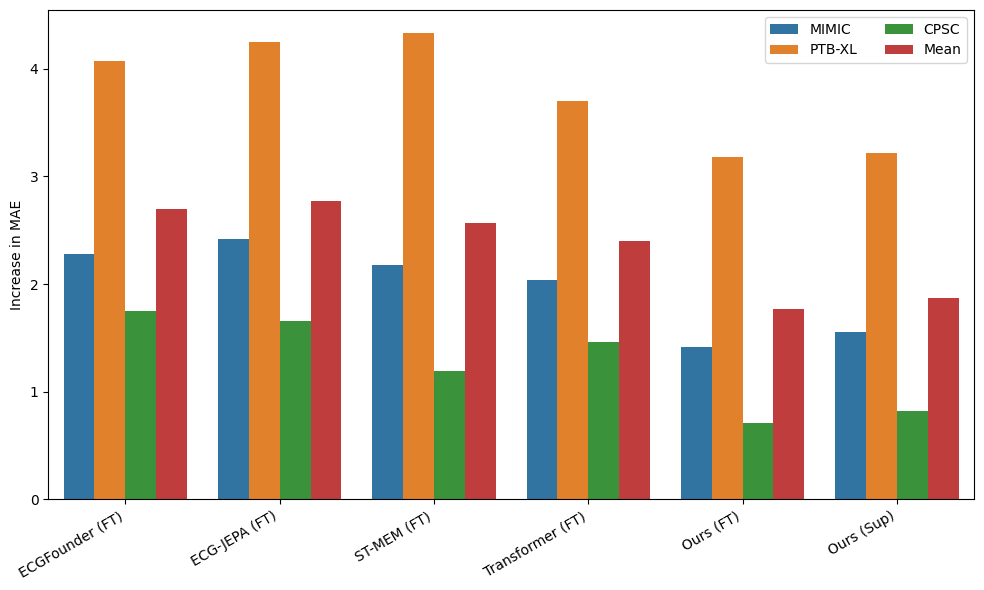

In [52]:
from matplotlib import pyplot as plt
import seaborn as sns
# Extract numeric part (mean before ±)
def plot_difference_in_mae(df, name):
    df = df.copy()
    def to_num(x):
        return float(str(x).split("±")[0].strip())

    for col in df.columns:
        df[col] = df[col].apply(to_num)

    # Compute differences
    increases = pd.DataFrame(index=df.index)
    # increases["CODE"] = df["valid_mae (mean ± std)"]
    increases["MIMIC"] = df["test_mae_mimic/dataloader_idx_1 (mean ± std)"] - df["valid_mae (mean ± std)"]
    increases["PTB-XL"] = df["test_mae_ptbxl/dataloader_idx_0 (mean ± std)"] - df["valid_mae (mean ± std)"]
    increases["CPSC"] = df["test_mae_cpsc/dataloader_idx_2 (mean ± std)"] - df["valid_mae (mean ± std)"]
    increases['Mean'] = df["mean_mae (mean ± std)"] - df["valid_mae (mean ± std)"]

    # rename index with
    increases = increases.rename(index=rename_map_2)
    print(increases)

    # Melt for seaborn
    increases_melted = increases.reset_index().melt(id_vars='group', var_name='Dataset', value_name='MAE Increase')
    plt.figure(figsize=(10, 6))
    sns.barplot(data=increases_melted, x='group', y='MAE Increase', hue='Dataset')
    plt.ylabel("Increase in MAE")
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig(name, dpi=300)

plot_difference_in_mae(age_ft, "figs/mae_increase_age_prediction.svg")


## linear probing

In [50]:
age_lp = formatted_df_age[formatted_df_age.index.str.endswith("_lp")]
styled_df_age_lp = age_lp.style.apply(style_mean_column_min)
styled_df_age_lp

,test_rsmape_0_mimic/dataloader_idx_1 (mean ± std),test_mae_mimic/dataloader_idx_1 (mean ± std),test_rsmape_0_ptbxl/dataloader_idx_0 (mean ± std),test_mae_ptbxl/dataloader_idx_0 (mean ± std),test_rsmape_0_cpsc/dataloader_idx_2 (mean ± std),test_mae_cpsc/dataloader_idx_2 (mean ± std),_runtime (mean ± std),valid_mae (mean ± std),valid_rsmape_0 (mean ± std),mean_mae (mean ± std),mean_rsmape (mean ± std)
,,,,,,,,,,,
group,,,,,,,,,,,
best_ecgfm_lp,0.077 ± 0.001,9.305 ± 0.010,0.080 ± 0.001,10.977 ± 0.051,0.081 ± 0.001,8.569 ± 0.053,5826.367 ± 15.400,7.606 ± 0.027,0.079 ± 0.001,9.617 ± 0.032,0.079 ± 0.001
best_jepa_lp,0.083 ± 0.001,9.985 ± 0.004,0.083 ± 0.001,11.308 ± 0.008,0.083 ± 0.001,8.911 ± 0.016,19668.175 ± 49.091,7.938 ± 0.026,0.083 ± 0.001,10.068 ± 0.006,0.083 ± 0.001
best_stmem_lp,0.097 ± 0.001,11.544 ± 0.047,0.096 ± 0.001,12.755 ± 0.010,0.104 ± 0.001,11.122 ± 0.018,13216.987 ± 63.599,12.320 ± 0.021,0.127 ± 0.001,11.807 ± 0.024,0.099 ± 0.001
best_trans_lp,0.086 ± 0.001,10.310 ± 0.011,0.092 ± 0.001,12.199 ± 0.027,0.094 ± 0.001,9.966 ± 0.034,2364.351 ± 13.709,9.432 ± 0.028,0.097 ± 0.001,10.825 ± 0.023,0.091 ± 0.001
best_xlstm_lp,0.078 ± 0.001,9.332 ± 0.006,0.080 ± 0.001,10.909 ± 0.007,0.080 ± 0.001,8.486 ± 0.014,2105.341 ± 4.881,8.829 ± 0.023,0.092 ± 0.001,9.576 ± 0.003,0.079 ± 0.001


                  MIMIC  PTB-XL   CPSC   Mean
group                                        
ECGFounder (LP)   1.699   3.371  0.963  2.011
ECG-JEPA (LP)     2.047   3.370  0.973  2.130
ST-MEM (LP)      -0.776   0.435 -1.198 -0.513
Transformer (LP)  0.878   2.767  0.534  1.393
Ours (LP)         0.503   2.080 -0.343  0.747


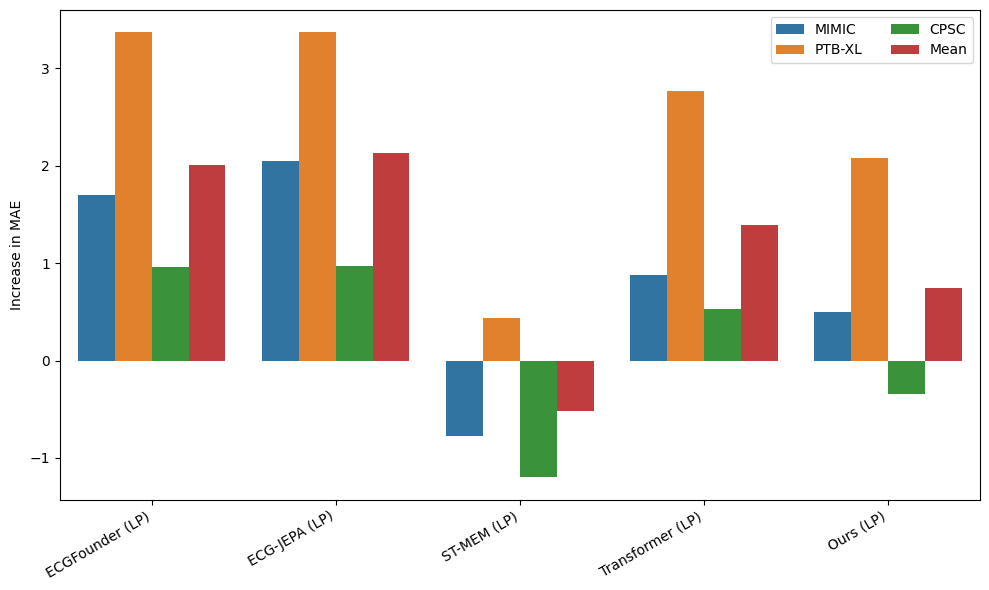

In [53]:
plot_difference_in_mae(age_lp, "figs/mae_increase_age_prediction_lp.svg")

## Latex table generation

In [55]:

def make_age_table(age_ft, age_lp):
    # order in which rows appea

    # columns we want to display
    metrics = [
        ("valid_mae (mean ± std)", "MAE"),
        ("valid_rsmape_0 (mean ± std)", "RSMAPE"),
        ("test_mae_mimic/dataloader_idx_1 (mean ± std)", "MAE"),
        ("test_rsmape_0_mimic/dataloader_idx_1 (mean ± std)", "RSMAPE"),
        ("test_mae_ptbxl/dataloader_idx_0 (mean ± std)", "MAE"),
        ("test_rsmape_0_ptbxl/dataloader_idx_0 (mean ± std)", "RSMAPE"),
        ("test_mae_cpsc/dataloader_idx_2 (mean ± std)", "MAE"),
        ("test_rsmape_0_cpsc/dataloader_idx_2 (mean ± std)", "RSMAPE"),
        ("mean_mae (mean ± std)", "MAE"),
        ("mean_rsmape (mean ± std)", "RSMAPE"),
    ]

    # highlight values in each group
    ft_fmt = apply_highlight(age_ft, order_ft, method='min')
    lp_fmt = apply_highlight(age_lp, order_lp, method='min')


    # build LaTeX table
    latex = []
    latex.append(r"\begin{table*}[ht]")
    latex.append(r"\resizebox{\textwidth}{!}{")
    latex.append(r"    \begin{tabular}{l|cc|cc|cc|cc|cc}")
    latex.append(r"    \toprule")
    latex.append(r"    \textbf{Methods} & "
                 r"\multicolumn{2}{c|}{\textbf{CODE-15 (val)}} & "
                 r"\multicolumn{2}{c|}{\textbf{MIMIC}} & "
                 r"\multicolumn{2}{c|}{\textbf{PTB-XL}} & "
                 r"\multicolumn{2}{c|}{\textbf{CPSC}} & "
                 r"\multicolumn{2}{c}{\textbf{Mean}} \\")
    latex.append(r"     & MAE & RSMAPE & MAE & RSMAPE & MAE & RSMAPE & MAE & RSMAPE & MAE & RSMAPE \\")
    latex.append(r"    \midrule")

    # supervised
    latex.append(r"    \multicolumn{11}{c}{\textbf{Supervised}} \\")
    latex.append(r"    \midrule")
    row = age_ft.loc["best_xlstm_sup"]
    latex.append(row_to_latex("best_xlstm_sup", row))

    # linear probing
    latex.append(r"    \midrule")
    latex.append(r"    \multicolumn{11}{c}{\textbf{Linear Probing}} \\")
    latex.append(r"    \midrule")
    for name in order_lp:
        row = lp_fmt.loc[name]
        latex.append(row_to_latex(name, row))

    # finetuning
    latex.append(r"    \midrule")
    latex.append(r"    \multicolumn{11}{c}{\textbf{Finetuning}} \\")
    latex.append(r"    \midrule")
    for name in order_ft:
        row = ft_fmt.loc[name]
        latex.append(row_to_latex(name, row))

    # footer
    latex.append(r"    \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(r"}")
    latex.append(r"\caption{Performance comparison for age prediction trained on CODE-15 and tested on MIMIC, PTB-XL, and CPSC datasets. Results are reported as mean ± std for MAE and RSMAPE.}")
    latex.append(r"\label{tab:age_regression_results}")
    latex.append(r"\end{table*}")

    return "\n".join(latex)

print(make_age_table(age_ft, age_lp))

\begin{table*}[ht]
\resizebox{\textwidth}{!}{
    \begin{tabular}{l|cc|cc|cc|cc|cc}
    \toprule
    \textbf{Methods} & \multicolumn{2}{c|}{\textbf{CODE-15 (val)}} & \multicolumn{2}{c|}{\textbf{MIMIC}} & \multicolumn{2}{c|}{\textbf{PTB-XL}} & \multicolumn{2}{c|}{\textbf{CPSC}} & \multicolumn{2}{c}{\textbf{Mean}} \\
     & MAE & RSMAPE & MAE & RSMAPE & MAE & RSMAPE & MAE & RSMAPE & MAE & RSMAPE \\
    \midrule
    \multicolumn{11}{c}{\textbf{Supervised}} \\
    \midrule
\textbf{ours (xlstm)} & 7.884 ± 0.013 & 0.081 ± 0.001 & 9.439 ± 0.044 & 0.079 ± 0.001 & 11.103 ± 0.062 & 0.081 ± 0.001 & 8.709 ± 0.084 & 0.082 ± 0.001 & 9.750 ± 0.047 & 0.081 ± 0.001 \\
    \midrule
    \multicolumn{11}{c}{\textbf{Linear Probing}} \\
    \midrule
ST-MEM & 12.320 ± 0.021 & 0.127 ± 0.001 & 11.544 ± 0.047 & 0.097 ± 0.001 & 12.755 ± 0.010 & 0.096 ± 0.001 & 11.122 ± 0.018 & 0.104 ± 0.001 & 11.807 ± 0.024 & 0.099 ± 0.001 \\
ECG-JEPA & \underline{7.938 ± 0.026} & \underline{0.083 ± 0.001} & 9.985 ± 0.004 & 0.08

# LAB tests

In [56]:
lab_test_records = get_records("train-lab", metrics=["test_auroc_avg", "test_f1_avg", "test_acc_avg", '_runtime'])
formatted_df_lab_tests = get_dataframe_from_records(lab_test_records)

100%|██████████| 55/55 [00:01<00:00, 54.34it/s]

## Finetuning

In [57]:
lab_ft = formatted_df_lab_tests[formatted_df_lab_tests.index.isin(ft_groups)]
styled_lab_ft = lab_ft.style.apply(style_mean_column)
styled_lab_ft

,test_auroc_avg (mean ± std),test_f1_avg (mean ± std),test_acc_avg (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_ft,0.661 ± 0.001,0.358 ± 0.001,0.372 ± 0.001,10821.271 ± 80.940
best_jepa_ft,0.686 ± 0.001,0.371 ± 0.001,0.384 ± 0.001,144700.842 ± 716.667
best_stmem_ft,0.681 ± 0.002,0.376 ± 0.004,0.385 ± 0.003,48944.694 ± 2403.319
best_trans_ft,0.666 ± 0.002,0.372 ± 0.005,0.381 ± 0.003,2874.121 ± 103.414
best_xlstm_ft,0.691 ± 0.001,0.382 ± 0.001,0.389 ± 0.001,7741.541 ± 76.971
best_xlstm_sup,0.640 ± 0.007,0.354 ± 0.007,0.367 ± 0.003,2447.484 ± 117.166


## linear probing

In [58]:
lab_lp = formatted_df_lab_tests[formatted_df_lab_tests.index.str.endswith("_lp")]
styled_lab_lp = lab_lp.style.apply(style_mean_column)
styled_lab_lp

,test_auroc_avg (mean ± std),test_f1_avg (mean ± std),test_acc_avg (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_ecgfm_lp,0.653 ± 0.001,0.342 ± 0.001,0.362 ± 0.001,6478.227 ± 52.923
best_jepa_lp,0.666 ± 0.001,0.348 ± 0.001,0.367 ± 0.001,22933.045 ± 81.621
best_stmem_lp,0.657 ± 0.001,0.344 ± 0.001,0.364 ± 0.001,16590.173 ± 73.230
best_trans_lp,0.672 ± 0.001,0.350 ± 0.001,0.369 ± 0.001,4932.921 ± 72.590
best_xlstm_lp,0.681 ± 0.001,0.362 ± 0.001,0.376 ± 0.001,5857.456 ± 44.109


In [ ]:
def make_lab_table(ft_df, lp_df):
    # metrics to show
    metrics = [
        ("test_acc_avg (mean ± std)", "ACC"),
        ("test_f1_avg (mean ± std)", "F1"),
        ("test_auroc_avg (mean ± std)", "AUC"),
    ]

    lp_fmt = apply_highlight(lp_df, order_lp, method='max')
    ft_fmt = apply_highlight(ft_df, order_ft, method='max')

    latex = []
    latex.append(r"\begin{table}[ht]")
    latex.append(r"\centering")
    latex.append(r"\resizebox{0.75\textwidth}{!}{")
    latex.append(r"    \begin{tabular}{l|c|c|c}")
    latex.append(r"    \toprule")
    latex.append(r"    \textbf{Methods} & ACC & F1 & AUC \\")
    latex.append(r"    \midrule")

    # supervised
    latex.append(r"    \multicolumn{4}{c}{\textbf{Supervised}} \\")
    latex.append(r"    \midrule")
    row = ft_df.loc["best_xlstm_sup"]
    latex.append(row_to_latex("best_xlstm_sup", row))

    # LP
    latex.append(r"    \midrule")
    latex.append(r"    \multicolumn{4}{c}{\textbf{Linear Probing}} \\")
    latex.append(r"    \midrule")
    for name in order_lp:
        row = lp_fmt.loc[name]
        latex.append(row_to_latex(name, row))

    # FT
    latex.append(r"    \midrule")
    latex.append(r"    \multicolumn{4}{c}{\textbf{Finetuning}} \\")
    latex.append(r"    \midrule")
    for name in order_ft:
        row = ft_fmt.loc[name]
        latex.append(row_to_latex(name, row))

    latex.append(r"    \hline")
    latex.append(r"    \end{tabular}")
    latex.append(r"}")
    latex.append(r"\caption{Performance comparison for the LAB test task (ACC, F1, AUC)}")
    latex.append(r"\label{tab:lab_test_results}")
    latex.append(r"\end{table}")

    return "\n".join(latex)

print(make_lab_table(lab_ft, lab_lp))

# Mortality prediction

In [63]:
mortality_test_records = get_records("train-mortality", metrics=["test_loss", "test_ci"])
formatted_mortality_df = get_dataframe_from_records(mortality_test_records)

100%|██████████| 55/55 [00:01<00:00, 54.79it/s]


## Fine-tuning

In [64]:
mortality_ft = formatted_mortality_df[formatted_mortality_df.index.isin(ft_groups)]
styled_mortality_df = mortality_ft.style.apply(style_mean_column)
styled_mortality_df

,test_loss (mean ± std),test_ci (mean ± std)
,,
group,,
best_ecgfm_ft,1.777 ± 0.001,0.688 ± 0.002
best_jepa_ft,1.220 ± 0.002,0.706 ± 0.001
best_stmem_ft,1.220 ± 0.001,0.694 ± 0.004
best_trans_ft,1.789 ± 0.003,0.701 ± 0.004
best_xlstm_ft,1.780 ± 0.001,0.710 ± 0.001
best_xlstm_sup,1.804 ± 0.007,0.630 ± 0.016


## Linear probing

In [65]:
mortality_lp = formatted_mortality_df[formatted_mortality_df.index.isin(lp_groups)]
styled_mortality_lp = mortality_lp.style.apply(style_mean_column)
styled_mortality_lp

,test_loss (mean ± std),test_ci (mean ± std)
,,
group,,
best_ecgfm_lp,1.782 ± 0.001,0.683 ± 0.001
best_jepa_lp,1.780 ± 0.001,0.706 ± 0.001
best_stmem_lp,1.774 ± 0.001,0.697 ± 0.001
best_trans_lp,1.772 ± 0.001,0.695 ± 0.001
best_xlstm_lp,1.778 ± 0.002,0.703 ± 0.001


In [ ]:
def make_surv_table(ft_df, lp_df):
    metrics = [
        ("test_ci (mean ± std)", "CI", "max")        # higher = better
    ]

    ft_fmt = apply_highlight(ft_df, order_ft, method='max')
    lp_fmt = apply_highlight(lp_df, order_lp, method='max')

    latex = []
    latex.append(r"\begin{table}[ht]")
    latex.append(r"\centering")
    latex.append(r"\resizebox{0.65\textwidth}{!}{")
    latex.append(r"    \begin{tabular}{l|c}")
    latex.append(r"    \toprule")
    latex.append(r"    \textbf{Methods} & CI \\")
    latex.append(r"    \midrule")

    # supervised
    latex.append(r"    \multicolumn{2}{c}{\textbf{Supervised}} \\")
    latex.append(r"    \midrule")
    row = ft_df.loc["best_xlstm_sup"]
    latex.append(row_to_latex("best_xlstm_sup", row))

    latex.append(r"    \midrule")
    latex.append(r"    \multicolumn{4}{c}{\textbf{Linear Probing}} \\")
    latex.append(r"    \midrule")
    for name in order_lp:
        row = lp_fmt.loc[name]
        latex.append(row_to_latex(name, row))

    # Finetuning
    latex.append(r"    \midrule")
    latex.append(r"    \multicolumn{2}{c}{\textbf{Finetuning}} \\")
    latex.append(r"    \midrule")
    for name in order_ft:
        row = ft_fmt.loc[name]
        latex.append(row_to_latex(name, row))

    latex.append(r"    \hline")
    latex.append(r"    \end{tabular}")
    latex.append(r"}")
    latex.append(r"\caption{Performance comparison for mortality prediction task.}")
    latex.append(r"\label{tab:mortality_results}")
    latex.append(r"\end{table}")

    return "\n".join(latex)

print(make_surv_table(mortality_ft, mortality_lp))

# Time analysis

adding index: best_ecgfm_ft
adding index: best_ecgfm_lp
adding index: best_jepa_ft
adding index: best_jepa_lp
adding index: best_stmem_ft
adding index: best_stmem_lp
adding index: best_trans_ft
adding index: best_trans_lp
adding index: best_xlstm_ft
adding index: best_xlstm_lp
adding index: best_xlstm_sup


/tmp/ipykernel_2688123/3666395277.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=runtime_df, x=x_labels, y='runtime', palette=colors)
/tmp/ipykernel_2688123/3666395277.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=22)


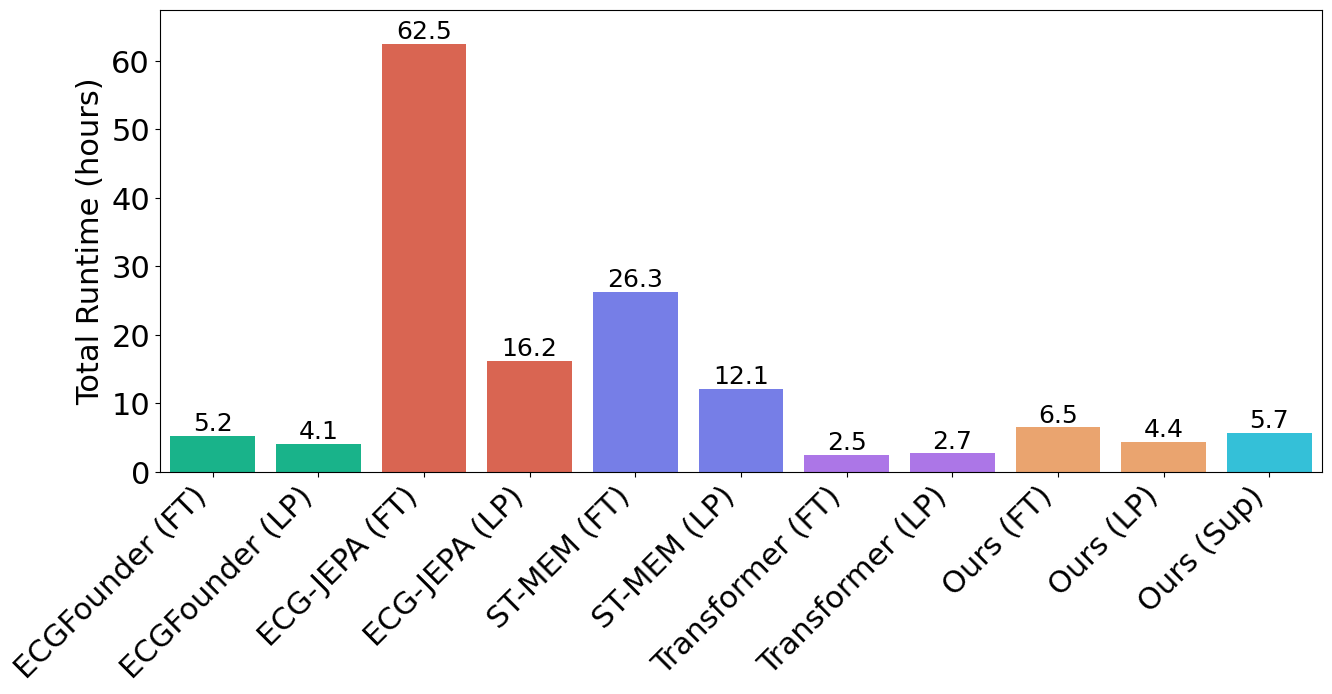

In [68]:
import seaborn as sns 
from matplotlib import pyplot as plt 
from plotly.colors import qualitative

# fig size
plt.figure(figsize=(15, 6))

# Increase font sizes for axis labels and tick labels
# sns.set_context("notebook", font_scale=1.5)  # font_scale increases all text sizes

dfs = []
for records in [records_ptb_xl, records_cpsc, records_mit_cls, records_mit_r_peaks, records_exe_r, records_sleep_apnea, records_ppg, records_age, lab_test_records]:
    df = pd.DataFrame(records)
    df = df.groupby("group").agg('mean')
    df = df[df.index.isin(ft_groups) | df.index.isin(lp_groups)]
    dfs.append(df)

# for each row on all the dfs sum the runtime
# new dataframe with rows as group
runtime_data = {}
for df in dfs:
    for index, row in df.iterrows():
        if index not in runtime_data.keys():
            print('adding index:', index)
            runtime_data[index] =  0
        # check if runtime is in df
        runtime_data[index] += row['_runtime']

runtime_df = pd.DataFrame.from_dict(runtime_data, orient='index') 
runtime_df = runtime_df.rename(columns={0: 'runtime'})
runtime_df['runtime'] = runtime_df['runtime'] / 3600
colors = [colors_idxs[name] for name in runtime_df.index]
x_labels = [rename_map_2[name] for name in runtime_df.index]
ax = sns.barplot(data=runtime_df, x=x_labels, y='runtime', palette=colors)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=22)
# ax.set_xlabel('Method', fontsize=22)
ax.set_ylabel('Total Runtime (hours)', fontsize=22)
ax.tick_params(axis='y', labelsize=22)
# set max y to + 1
ax.set_ylim(0, runtime_df['runtime'].max() + 5)

# add on top of the bar the number
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', rotation=0, fontsize=18)

# save figure
plt.savefig('figs/runtime_comparison.svg', bbox_inches='tight', dpi=300)

In [69]:
time_groups = ['time_xlstm_ft', 'time_xlstm_lp', 'time_xlstm_sup', 'time_ecgfm_ft', 'time_ecgfm_lp', 'time_jepa_ft', 'time_jepa_lp', 'time_stmem_ft', 'time_stmem_lp']
df_time_ptbxl = pd.DataFrame(get_records("train-ptbxl-diagnosis_superclass-multilabel", metrics=metrics, pattern=(lambda run: run.group is not None and run.group.startswith("time_"))))
df_time_ptbxl = df_time_ptbxl[df_time_ptbxl['group'].isin(time_groups)]
df_time_ptbxl


100%|██████████| 485/485 [01:12<00:00,  6.68it/s]


,group,test_acc,test_f1,test_auroc,test_auprc,_runtime
0,time_ecgfm_ft,0.895086,0.750108,0.933676,0.830676,501.421230
1,time_ecgfm_lp,0.886169,0.713248,0.920982,0.807349,268.674076
2,time_jepa_lp,0.872429,0.699938,0.906681,0.774658,1726.364747
3,time_jepa_ft,0.883894,0.733656,0.923555,0.808435,4031.126119
4,time_stmem_lp,0.852138,0.595398,0.874853,0.711138,1147.352642
5,time_stmem_ft,0.891447,0.731853,0.930512,0.824100,2776.311824
8,time_xlstm_lp,0.877616,0.693010,0.918609,0.795509,272.991870
9,time_xlstm_ft,0.884986,0.719882,0.928430,0.816779,459.003388
10,time_xlstm_sup,0.863330,0.659517,0.891528,0.741819,493.882216


/tmp/ipykernel_2688123/2260238928.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=runtime_ptbxl_df, x=x_labels, y='runtime', palette=colors)
/tmp/ipykernel_2688123/2260238928.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=22)


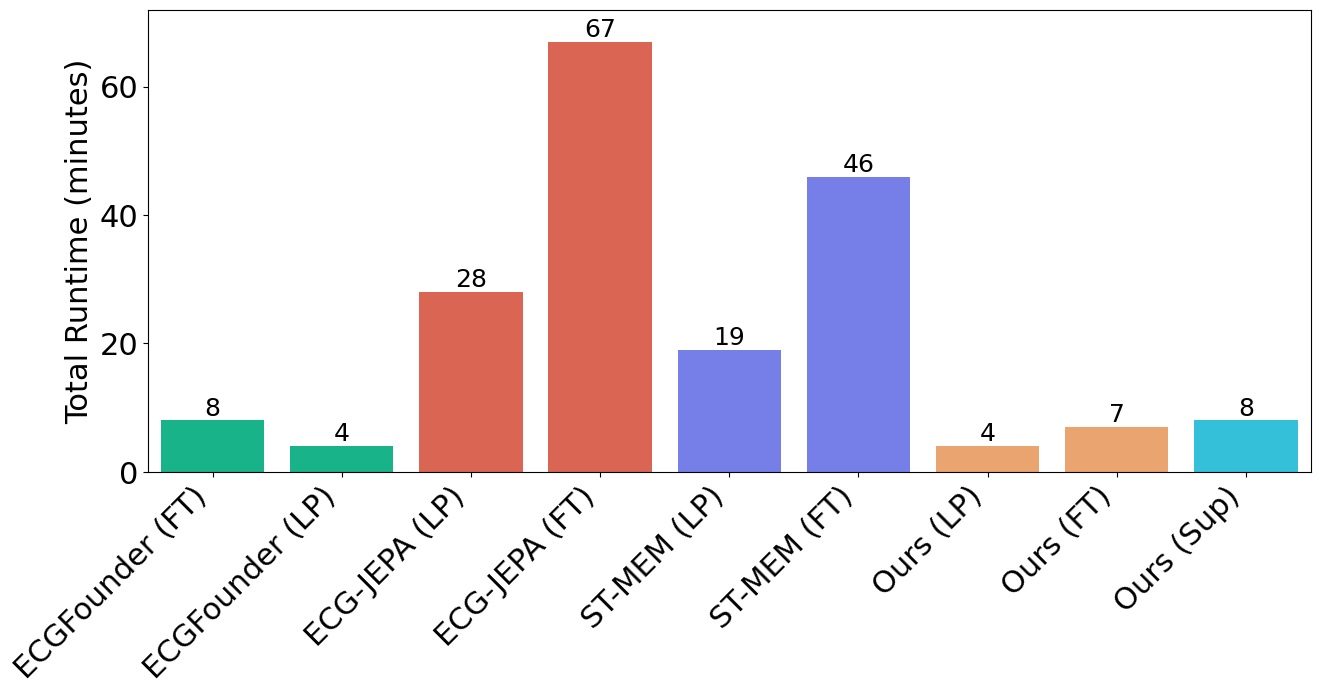

In [70]:
runtime_ptbxl_df = df_time_ptbxl.rename(columns={'_runtime': 'runtime'})
runtime_ptbxl_df['runtime'] = runtime_ptbxl_df['runtime'] // 60
# set group index
runtime_ptbxl_df = runtime_ptbxl_df.set_index('group')

plt.figure(figsize=(15, 6))

colors = [colors_idxs[name.replace('time_', 'best_')] for name in runtime_ptbxl_df.index]
x_labels = [rename_map_2[name.replace('time_', 'best_')] for name in runtime_ptbxl_df.index]
ax = sns.barplot(data=runtime_ptbxl_df, x=x_labels, y='runtime', palette=colors)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=22)
# ax.set_xlabel('Method', fontsize=22)
ax.set_ylabel('Total Runtime (minutes)', fontsize=22)
ax.tick_params(axis='y', labelsize=22)
# set max y to + 1
ax.set_ylim(0, runtime_ptbxl_df['runtime'].max() + 5)

# add on top of the bar the number
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', rotation=0, fontsize=18)

# save figure
plt.savefig('figs/runtime_comparison_ptbxl.svg', bbox_inches='tight', dpi=300)

# RANKING

In [157]:

dfs = []
for i, records in enumerate([records_ptb_xl, records_cpsc, records_mit_cls, records_sleep_apnea, records_ppg, records_exe_r, records_mit_r_peaks, records_age, lab_test_records, mortality_test_records]):
    df = pd.DataFrame(records)
    if i == 7: df = add_mean(df) # for age prediction add the mean rsmape
    df = df.groupby("group").agg('mean')
    df = df[df.index.isin(ft_groups) | df.index.isin(lp_groups)]
    dfs.append(df)

In [158]:
categories = ['PTB-XL', 'CPSC2018', 'MIT-BIH', 'Apnea-ECG', 'PPG', 'Exercise', 'R-PEAK', 'Age', 'LAB test', 'Mortality']
categories_metric = ['PTB-XL / AUC', 'CPSC2018 / AUC', 'MIT-BIH / F1', 'Sleep Apnea / AUC', 'PPG / AUC', 'Exercise / F1', 'R-Peaks / F1', 'Age / MAE', 'LAB test / AUC', 'Mortality / CI']
methods = ['ST-MEM', 'ECG-JEPA', 'ECG Founder', 'SimDINOv2\nTransformer', 'xECG', 'Supervised\nxLSTM']

reindex_ft = [4, 3, 5, 0, 1, 2]

def get_full_results(dfs, reindex, is_ft):
    end = 'ft' if is_ft else 'lp'
    data = {
        'PTB-XL / AUC': [   dfs[0].loc[f'best_stmem_{end}']['test_auroc'],
                            dfs[0].loc[f'best_jepa_{end}']['test_auroc'], 
                            dfs[0].loc[f'best_ecgfm_{end}']['test_auroc'], 
                            dfs[0].loc[f'best_trans_{end}']['test_auroc'], 
                            dfs[0].loc[f'best_xlstm_{end}']['test_auroc']],
        'CPSC2018 / AUC': [ dfs[1].loc[f'best_stmem_{end}']['test_auroc'],
                            dfs[1].loc[f'best_jepa_{end}']['test_auroc'], 
                            dfs[1].loc[f'best_ecgfm_{end}']['test_auroc'],
                            dfs[1].loc[f'best_trans_{end}']['test_auroc'],
                            dfs[1].loc[f'best_xlstm_{end}']['test_auroc']],
        'MIT-BIH / F1': [   dfs[2].loc[f'best_stmem_{end}']['test_f1/mean'],
                            dfs[2].loc[f'best_jepa_{end}']['test_f1/mean'], 
                            dfs[2].loc[f'best_ecgfm_{end}']['test_f1/mean'],
                            dfs[2].loc[f'best_trans_{end}']['test_f1/mean'],
                            dfs[2].loc[f'best_xlstm_{end}']['test_f1/mean']],
        'Sleep Apnea / AUC': [ dfs[3].loc[f'best_stmem_{end}']['test_auc'],
                            dfs[3].loc[f'best_jepa_{end}']['test_auc'], 
                            dfs[3].loc[f'best_ecgfm_{end}']['test_auc'],
                            dfs[3].loc[f'best_trans_{end}']['test_auc'],
                            dfs[3].loc[f'best_xlstm_{end}']['test_auc']],
        'PPG / AUC': [      dfs[4].loc[f'best_stmem_{end}']['test_auroc'],
                            dfs[4].loc[f'best_jepa_{end}']['test_auroc'], 
                            dfs[4].loc[f'best_ecgfm_{end}']['test_auroc'],
                            dfs[4].loc[f'best_trans_{end}']['test_auroc'],
                            dfs[4].loc[f'best_xlstm_{end}']['test_auroc']],
        'Exercise / F1': [  dfs[5].loc[f'best_stmem_{end}']['test_f1_20'],
                            dfs[5].loc[f'best_jepa_{end}']['test_f1_20'], 
                            dfs[5].loc[f'best_ecgfm_{end}']['test_f1_20'],
                            dfs[5].loc[f'best_trans_{end}']['test_f1_20'],
                            dfs[5].loc[f'best_xlstm_{end}']['test_f1_20']],
        'R-Peaks / F1': [  dfs[6].loc[f'best_stmem_{end}']['test_f1_20'],
                            dfs[6].loc[f'best_jepa_{end}']['test_f1_20'], 
                            dfs[6].loc[f'best_ecgfm_{end}']['test_f1_20'],
                            dfs[6].loc[f'best_trans_{end}']['test_f1_20'],
                            dfs[6].loc[f'best_xlstm_{end}']['test_f1_20']],
        'Age / MAE': [      1 - dfs[7].loc[f'best_stmem_{end}']['mean_rsmape'],
                            1 - dfs[7].loc[f'best_jepa_{end}']['mean_rsmape'], 
                            1 - dfs[7].loc[f'best_ecgfm_{end}']['mean_rsmape'],
                            1 - dfs[7].loc[f'best_trans_{end}']['mean_rsmape'],
                            1 - dfs[7].loc[f'best_xlstm_{end}']['mean_rsmape']],
        'LAB test / AUC': [ dfs[8].loc[f'best_stmem_{end}']['test_auroc_avg'],
                            dfs[8].loc[f'best_jepa_{end}']['test_auroc_avg'],
                            dfs[8].loc[f'best_ecgfm_{end}']['test_auroc_avg'],
                            dfs[8].loc[f'best_trans_{end}']['test_auroc_avg'],
                            dfs[8].loc[f'best_xlstm_{end}']['test_auroc_avg']],
        'Mortality / CI': [ dfs[9].loc[f'best_stmem_{end}']['test_ci'],
                            dfs[9].loc[f'best_jepa_{end}']['test_ci'],
                            dfs[9].loc[f'best_ecgfm_{end}']['test_ci'],
                            dfs[9].loc[f'best_trans_{end}']['test_ci'],
                            dfs[9].loc[f'best_xlstm_{end}']['test_ci']]
    }# RANKING

    if is_ft:
        data['PTB-XL / AUC'].append(dfs[0].loc[f'best_xlstm_sup']['test_auroc'])
        data['CPSC2018 / AUC'].append(dfs[1].loc[f'best_xlstm_sup']['test_auroc'])
        data['MIT-BIH / F1'].append(dfs[2].loc[f'best_xlstm_sup']['test_f1/mean'])
        data['Sleep Apnea / AUC'].append(dfs[3].loc[f'best_xlstm_sup']['test_auc'])
        data['PPG / AUC'].append(dfs[4].loc[f'best_xlstm_sup']['test_auroc'])
        data['Exercise / F1'].append(dfs[5].loc[f'best_xlstm_sup']['test_f1_20'])
        data['R-Peaks / F1'].append(dfs[6].loc[f'best_xlstm_sup']['test_f1_20'])
        data['Age / MAE'].append(1 - dfs[7].loc[f'best_xlstm_sup']['mean_rsmape'])
        data['LAB test / AUC'].append(dfs[8].loc[f'best_xlstm_sup']['test_auroc_avg'])
        data['Mortality / CI'].append(dfs[9].loc[f'best_xlstm_sup']['test_ci'])

    df = pd.DataFrame(data, index=methods if is_ft else methods[:-1])
    df = df.reindex(df.index[reindex])
    return df

df_raw = get_full_results(dfs, reindex_ft, is_ft=True)
df_raw.head(n=10)



,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1,Age / MAE,LAB test / AUC,Mortality / CI
xECG,0.927636,0.981308,0.677293,0.868879,0.887048,0.968441,0.920580,0.924435,0.691337,0.709898
SimDINOv2\nTransformer,0.924652,0.965467,0.425415,0.604085,0.779656,0.632738,0.900353,0.914329,0.665705,0.700933
Supervised\nxLSTM,0.890728,0.951107,0.402199,0.783209,0.876326,0.965772,0.889045,0.919403,0.639621,0.629576
ST-MEM,0.929916,0.958217,0.644152,0.727026,0.642692,0.985623,0.937266,0.930290,0.681346,0.693980
ECG-JEPA,0.923336,0.965220,0.583076,0.587402,0.817771,0.858583,0.909293,0.925692,0.685941,0.705506
ECG Founder,0.930447,0.969354,0.207231,0.580191,0.845594,0.082417,0.011331,0.922704,0.661043,0.687948


In [149]:
reindex_lp = [4, 3, 0, 1, 2]
df_lp_raw = get_full_results(dfs, reindex_lp, is_ft=False)
df_lp_raw

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1,Age / MAE,LAB test / AUC,Mortality / CI
xECG,0.915361,0.967798,0.673956,0.797970,0.750782,0.891641,0.589917,0.920928,0.680821,0.702810
SimDINOv2\nTransformer,0.913967,0.950829,0.395488,0.649323,0.655769,0.301037,0.476394,0.909381,0.671669,0.695483
ST-MEM,0.867034,0.922097,0.436191,0.641669,0.653246,0.627345,0.564153,0.900687,0.657380,0.697337
ECG-JEPA,0.902226,0.961038,0.496206,0.546437,0.476940,0.526109,0.444294,0.916946,0.666062,0.706260
ECG Founder,0.917335,0.961727,0.206484,0.578864,0.640672,0.083204,0.010323,0.920547,0.652639,0.682990


In [209]:
# add color to each method for consistency
from plotly.colors import qualitative

colors = qualitative.Plotly[:len(df_raw)]
df_raw["color"] = [colors[idx] for idx in reindex_ft]
df_lp_raw["color"] = [colors[idx] for idx in reindex_lp]

# add some alpha for better visibility
pastel_colors = [f"{color}C0" for color in colors]  #
df_raw["pastel_color"] = [pastel_colors[idx] for idx in reindex_ft]
df_lp_raw["pastel_color"] = [pastel_colors[idx] for idx in reindex_lp]

df_raw.head(n=100)

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1,Age / MAE,LAB test / AUC,Mortality / CI,color,pastel_color
xECG,0.927636,0.981308,0.677293,0.868879,0.887048,0.968441,0.920580,0.924435,0.691337,0.709898,#FFA15A,#FFA15AC0
SimDINOv2\nTransformer,0.924652,0.965467,0.425415,0.604085,0.779656,0.632738,0.900353,0.914329,0.665705,0.700933,#AB63FA,#AB63FAC0
Supervised\nxLSTM,0.890728,0.951107,0.402199,0.783209,0.876326,0.965772,0.889045,0.919403,0.639621,0.629576,#19D3F3,#19D3F3C0
ST-MEM,0.929916,0.958217,0.644152,0.727026,0.642692,0.985623,0.937266,0.930290,0.681346,0.693980,#636EFA,#636EFAC0
ECG-JEPA,0.923336,0.965220,0.583076,0.587402,0.817771,0.858583,0.909293,0.925692,0.685941,0.705506,#EF553B,#EF553BC0
ECG Founder,0.930447,0.969354,0.207231,0.580191,0.845594,0.082417,0.011331,0.922704,0.661043,0.687948,#00CC96,#00CC96C0


In [210]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.colors import qualitative
import plotly.io as pio

pio.templates.default = "plotly"  # Set default template to white background
import numpy as np

categories_closed = categories + [categories[0]]

fig = go.Figure()
# Plot one radar chart for each method on separate axes (subplots)

rows = 3
cols = 2

min_v = 0. # df_raw.min().min()
max_v = 1.# df_raw.max().max()
print(f"Min value: {min_v}, Max value: {max_v}")

num_methods = len(df_raw)
rows = 2
cols = 3
fig = make_subplots(
    rows=rows, cols=cols,
    specs=[[{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}],
           [{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}]],
    subplot_titles=df_raw.index.tolist(),
    vertical_spacing=.1,  # Add vertical spacing between subplots
    horizontal_spacing=0.15  # Add horizontal spacing between subplots
)

gap = 1.0 / num_methods
padding = 0.06

for i, (idx, row) in enumerate(df_raw.iterrows()):

    current_row = (i // cols) + 1
    current_col = (i % cols) + 1
    #if i == len(df_z_scaled) -1:
    #    continue
    values = row.tolist()[:-2] + [row.tolist()[0]]  # close the loop
    print(values)
    trace = fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=idx,
            line=dict(width=3, color=row['color']),
            hoverinfo='skip',
        ),
        row=current_row, col=current_col
    )

    if i != 2:
        idx = i if i < 2 else i-1
        values = df_lp_raw.iloc[idx].tolist()[:-2] + [df_lp_raw.iloc[idx].tolist()[0]]  # close the loop
        values = [float(value) for value in values]
        print(values)
        fig.add_trace(
            go.Scatterpolar(
                r=values,
                theta=categories_closed,
                fill='toself',
                name=idx,
                line=dict(width=2, color=row['color']),
                hoverinfo='skip',
                marker=dict(
                    symbol="diamond",   # <-- change marker shape here
                    size=6,            # marker size
                    color=row['color']  # marker color
                ),
            ),
            row=current_row, 
            col=current_col
        )

    # Update polar layout for each subplot
    fig.update_layout({
        f'polar{i+1}': dict(
            angularaxis=dict(rotation=30),  # keep your rotation
            radialaxis=dict(
                visible=True, 
                range=[min_v, max_v], 
                showticklabels=True, 
                showline=True,
                showgrid=True,
                angle=-6,
                ticks="outside",
                tickcolor="white",
                ticklen=5,
                # tickvals=[0, 0.3, 0.7, 1],        # positions on the axis
                # ticktext=["0", "0.3", "0.7", "1"],  # what to display
                tickfont=dict(
                    size=10,       # font size of tick labels
                )
            )
        )
    })


# Optional: adjust overall layout for better spacing
fig.update_layout(
    width=18,   # 88mm in pixels (88mm * 2.835 pixels/mm)
    # height=166.3,   # Maintain aspect ratio (2:3 -> height = width * 2/3)
    font=dict(family="Helvetica", size=12),  # Sans-serif font, 6pt (between 5-7pt range)
    showlegend=False,  # Hide legend since each subplot is labeled
    margin=dict(l=50, r=50, t=20, b=20)  # Tight margins for Nature format
)

fig.update_annotations(
    font=dict(size=14, family="Helvetica"),
    showarrow=False,
    #yshift=5,  # Adjust vertical position of titles
)


# save pdf
fig.write_image("figs/radar_chart_methods.svg")
# fig.show()

Min value: 0.0, Max value: 1.0
[0.9276357054710388, 0.9813077569007873, 0.6772925734519959, 0.868879497051239, 0.8870480298995972, 0.9684410333633423, 0.9205804228782654, 0.9244354074199994, 0.6913368582725525, 0.7098982691764831, 0.9276357054710388]
[0.9153610706329346, 0.9677982926368713, 0.6739564895629883, 0.7979696989059448, 0.7507818222045899, 0.8916414499282836, 0.589917266368866, 0.9209279199441274, 0.6808214634656906, 0.7028095722198486, 0.9153610706329346]
[0.9246517300605774, 0.9654669046401978, 0.425414901971817, 0.6040854573249816, 0.7796563863754272, 0.6327379941940308, 0.9003530502319336, 0.9143293350934982, 0.6657052278518677, 0.7009331107139587, 0.9246517300605774]
[0.9139672040939331, 0.950829029083252, 0.3954884111881256, 0.6493229508399964, 0.6557693958282471, 0.30103652477264403, 0.4763944983482361, 0.9093806490302085, 0.6716692447662354, 0.6954825282096863, 0.9139672040939331]
[0.8907281041145325, 0.9511073231697083, 0.40219934582710265, 0.783209228515625, 0.87632

In [315]:
df_raw_score = df_raw.copy().drop(['pastel_color', 'color'], axis=1).mean(axis=1)
df_raw_score_lp = df_lp_raw.copy().drop(['pastel_color', 'color'], axis=1).mean(axis=1)

df_raw_score = df_raw_score.to_frame(name='raw_score')
df_raw_score_lp = df_raw_score_lp.to_frame(name='raw_score_lp')

df = df_raw_score.merge(df_raw_score_lp, left_index=True, right_index=True, how='left')
df['pastel_color'] = df_raw['pastel_color']
df = df.sort_values(by='raw_score', ascending=False)
df

,raw_score,raw_score_lp,pastel_color
xECG,0.855686,0.789199,#FFA15AC0
ST-MEM,0.813051,0.696714,#636EFAC0
ECG-JEPA,0.796182,0.664252,#EF553BC0
Supervised\nxLSTM,0.794699,NaN,#19D3F3C0
SimDINOv2\nTransformer,0.751333,0.661934,#AB63FAC0
ECG Founder,0.589826,0.565479,#00CC96C0


In [323]:
df["pastel_color"].str[:-2] + 'CC'

xECG                      #FFA15ACC
ST-MEM                    #636EFACC
ECG-JEPA                  #EF553BCC
Supervised\nxLSTM         #19D3F3CC
SimDINOv2\nTransformer    #AB63FACC
ECG Founder               #00CC96CC
Name: pastel_color, dtype: object

/tmp/ipykernel_2688123/1465253755.py:8: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2688123/1465253755.py:9: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



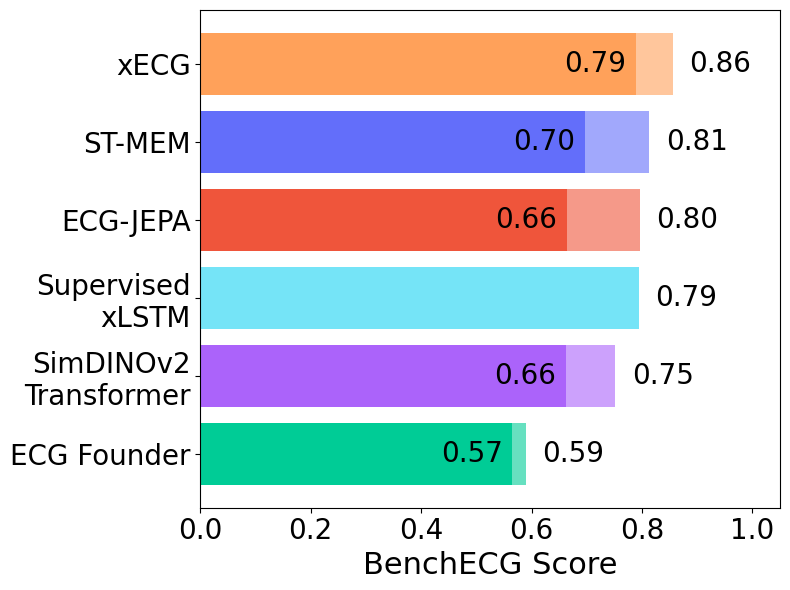

In [354]:
# plot combined bench score on index

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(df.index, df["raw_score"], color=df["pastel_color"].str[:-2] + '99')
bars = ax.barh(df.index, df["raw_score_lp"], color=df["pastel_color"].str[:-2] + 'FF')


ax.set_yticklabels(df.index, fontsize=20)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)

# Add labels to bars
for i, (value, label) in enumerate(zip(df["raw_score"], df.index)):
    ax.text(value + 0.03, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')

# Add labels to bars
for i, (value, label) in enumerate(zip(df["raw_score_lp"], df.index)):
    if value:
        ax.text(value - 0.13, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')


ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])                  # positions of the ticks
ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=20)

ax.set_xlabel('BenchECG Score', fontsize=22)
#ax.set_ylabel('Method', fontsize=12)
# ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
ax.invert_yaxis()  # Highest rank at top
ax.set_xlim([0, 1.05])  # Adjust x-axis limit

plt.tight_layout()
plt.savefig("figs/bench_ecg_scores.svg", dpi=300)


In [ ]:
df = df_raw.copy().drop(columns=["color", "pastel_color"])
# for every task get the rank
df["mean_rank"] = df.rank(ascending=False, method="min").mean(axis=1)

/tmp/ipykernel_2688123/1978114994.py:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2688123/1978114994.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2688123/1978114994.py:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2688123/1978114994.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



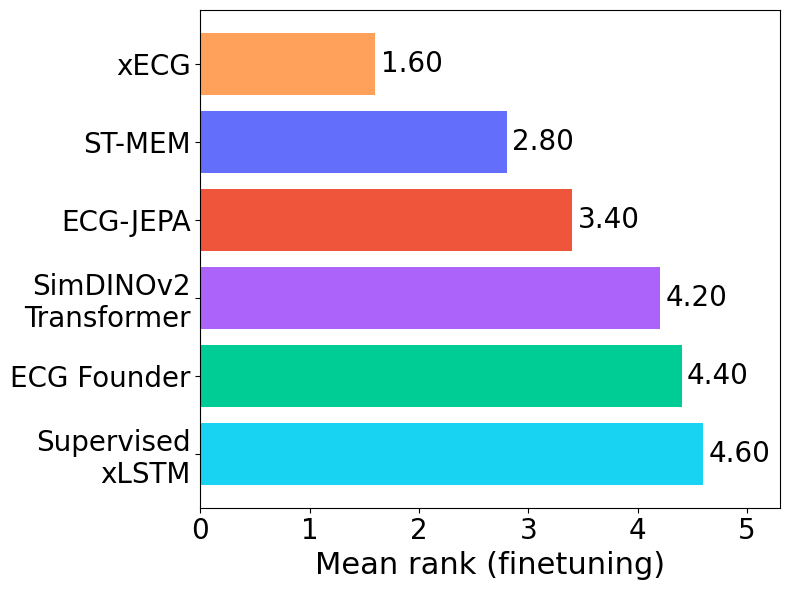

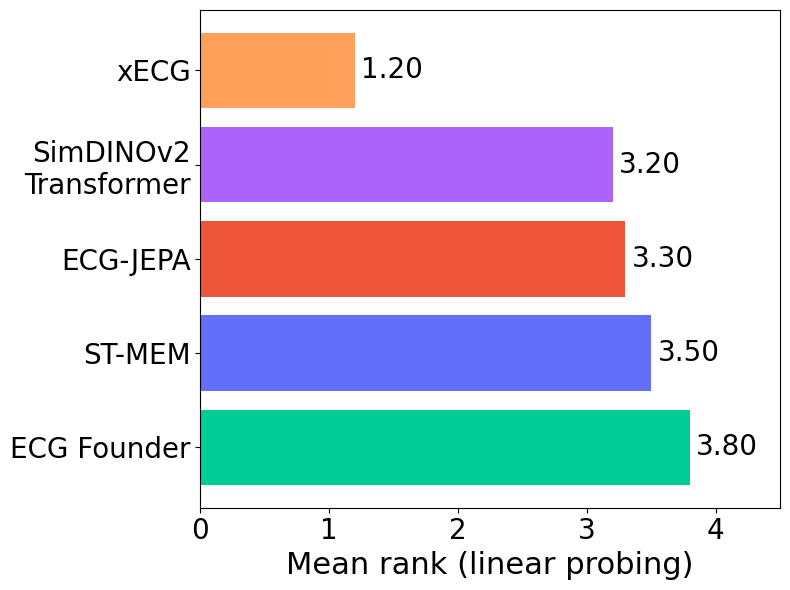

In [384]:
import matplotlib.pyplot as plt

def plot_bench_rank(df, name='mean_rank_methods.png', title=''):
    df_ranked_sorted = df.copy().drop(columns=["color", "pastel_color"])
    df_ranked_sorted["mean_rank"] = df_ranked_sorted.rank(ascending=False, method="min").mean(axis=1)
    df_ranked_sorted = df_ranked_sorted.sort_values(by="mean_rank", ascending=True)

    df_ranked_sorted["pastel_color"] = df["pastel_color"]

    norm = plt.Normalize(df_ranked_sorted["mean_rank"].min(), df_ranked_sorted["mean_rank"].max())

    fig, ax = plt.subplots(figsize=(8, 6))

    # Draw horizontal bars
    bars = ax.barh(df_ranked_sorted.index, df_ranked_sorted["mean_rank"], color=df_ranked_sorted["pastel_color"].str[:-2] + 'FF')
    ax.set_yticklabels(df_ranked_sorted.index, fontsize=20)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)

    # Add labels to bars
    for i, (value, label) in enumerate(zip(df_ranked_sorted["mean_rank"], df_ranked_sorted.index)):
        ax.text(value + 0.05, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')
    
    ax.set_xticks([0, 1, 2, 3, 4, 5])                  # positions of the ticks
    ax.set_xticklabels([0, 1, 2, 3, 4, 5], fontsize=20)

    # Format plo
    ax.set_xlabel(title, fontsize=22)
    #ax.set_ylabel('Method', fontsize=12)
    # ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, df_ranked_sorted["mean_rank"].max() + 0.7])  # Adjust x-axis limit

    plt.tight_layout()
    plt.savefig(name, dpi=300)

plot_bench_rank(df_raw, "figs/mean_rank_methods.svg", title='Mean rank (finetuning)')
plot_bench_rank(df_lp_raw, "figs/mean_rank_methods_lp.svg", title='Mean rank (linear probing)')

In [262]:
dfs_bench_score_ft = []

def get_metric_by_task(task):
    if task == categories[0] or task == categories[1] or task == categories[4]: # ptbxl or cpsc ppg
        return 'test_auroc'
    if task == categories[2]: # mit-bih
        return 'test_f1/mean'
    if task == categories[3]: # sleep apnea
        return 'test_auc'
    if task == categories[5] or task == categories[6]: # exe and rpeak
        return 'test_f1_20'
    if task == categories[7]: # age
        return 'mean_rsmape'
    if task == categories[8]: # lab
        return 'test_auroc_avg'
    if task == categories[9]: # mortality
        return 'test_ci'

for i, records in enumerate([records_ptb_xl, records_cpsc, records_mit_cls, records_sleep_apnea, records_ppg, records_exe_r, records_mit_r_peaks, records_age, lab_test_records, mortality_test_records]):
    df = pd.DataFrame(records)
    if i == 7: df = add_mean(df) # for age prediction add the mean rsmape
    # df = df.groupby("group").agg('mean')
    df = df[df['group'].isin(ft_groups) | df['group'].isin(lp_groups)]
    df['task'] = categories[i]
    if i == 7:
        df['task_score'] = 1 - df[get_metric_by_task(categories[i])]
    else:
        df['task_score'] = df[get_metric_by_task(categories[i])]
    dfs_bench_score_ft.append(df)



df_bench_score = pd.concat(dfs_bench_score_ft)
df_bench_score_ft = df_bench_score[df_bench_score['group'].isin(ft_groups)]
df_bench_score_lp = df_bench_score[df_bench_score['group'].isin(lp_groups)]


/tmp/ipykernel_2688123/3516366777.py:44: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2688123/3516366777.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2688123/3516366777.py:44: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_2688123/3516366777.py:45: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



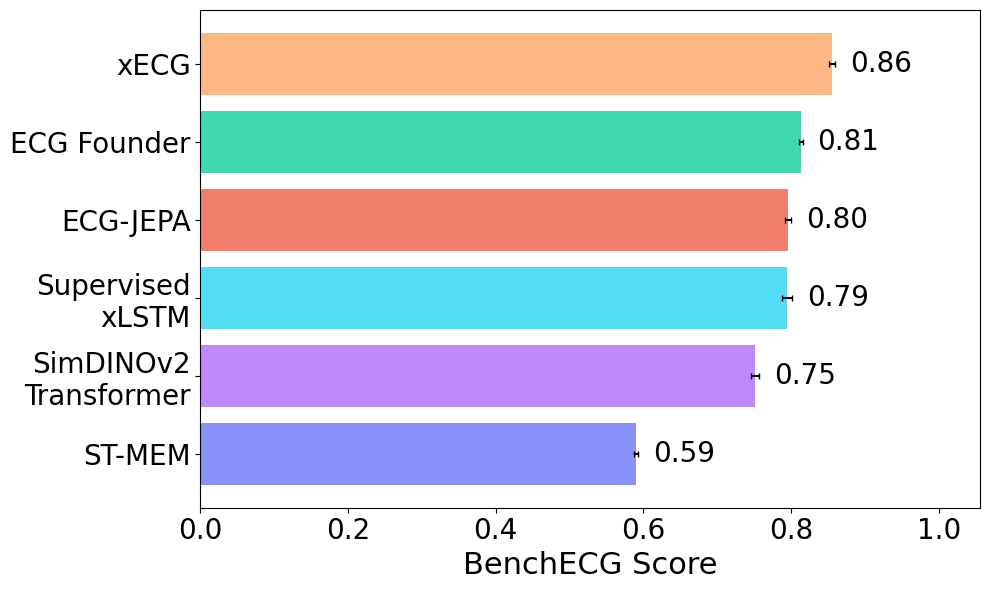

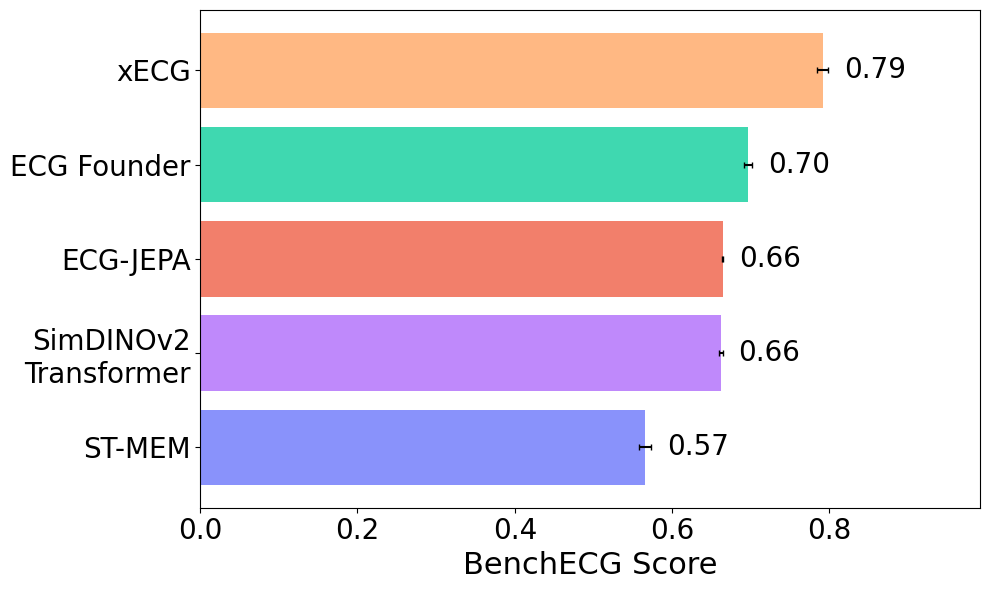

In [264]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from plotly.colors import qualitative
from matplotlib.ticker import MultipleLocator

def plot_bench_score(df, name='mean_score_methods.png'):
    df = df[['task', 'task_score', 'group']].copy()

    # Step 1: add run index inside each (task, group)
    df["pos"] = df.groupby(["task", "group"]).cumcount()
    df = df[df["pos"] < 5]

    # Step 2: average across tasks, for each (group, pos)
    per_pos = (
        df.groupby(["group", "pos"])["task_score"]
        .mean()
        .reset_index()
    )

    # Step 3: now aggregate across positions -> mean of means, std of means
    summary = (
        per_pos.groupby("group")["task_score"]
        .agg(mean_over_runs="mean", std_over_runs="std")
        .reset_index()
    )

    # add the color column back for plotting
    summary["pastel_color"] = pastel_colors[:len(summary)]
    summary.index = methods[:len(summary)]

    summary = summary.sort_values(by="mean_over_runs", ascending=False)



    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw horizontal bars
    bars = ax.barh(summary.index, summary["mean_over_runs"], color=summary["pastel_color"])
    # add std line
    ax.errorbar(summary["mean_over_runs"], summary.index, xerr=summary["std_over_runs"], fmt='none', c='black', capsize=2)

    ax.set_yticklabels(summary.index, fontsize=20)
    ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=20)

    # Add labels to bars
    for i, (value, std, label) in enumerate(zip(summary["mean_over_runs"], summary["std_over_runs"], summary.index)):
        ax.text(value + std + 0.02, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')

    # Format plot
    ax.set_xlabel('BenchECG Score', fontsize=22)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, summary["mean_over_runs"].max() + 0.2])  # Adjust x-axis limit

    plt.tight_layout()
    plt.savefig(name, dpi=300)

plot_bench_score(df_bench_score_ft, name='figs/mean_score_methods.svg')
plot_bench_score(df_bench_score_lp, name='figs/mean_score_methods_lp.svg')

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1,Age / MAE,LAB test / AUC,Mortality / CI,color,pastel_color
xECG,0.927636,0.981308,0.677293,0.868879,0.887048,0.968441,0.920580,0.924435,0.691337,0.709898,#FFA15A,#FFA15AC0
SimDINOv2\nTransformer,0.924652,0.965467,0.425415,0.604085,0.779656,0.632738,0.900353,0.914329,0.665705,0.700933,#AB63FA,#AB63FAC0
Supervised\nxLSTM,0.890728,0.951107,0.402199,0.783209,0.876326,0.965772,0.889045,0.919403,0.639621,0.629576,#19D3F3,#19D3F3C0
ST-MEM,0.929916,0.958217,0.644152,0.727026,0.642692,0.985623,0.937266,0.930290,0.681346,0.693980,#636EFA,#636EFAC0
ECG-JEPA,0.923336,0.965220,0.583076,0.587402,0.817771,0.858583,0.909293,0.925692,0.685941,0.705506,#EF553B,#EF553BC0
ECG Founder,0.930447,0.969354,0.207231,0.580191,0.845594,0.082417,0.011331,0.922704,0.661043,0.687948,#00CC96,#00CC96C0


In [266]:
def plot_lp_ft_diff(df_ft, df_lp):
    # not consider last df_ft
    df_ft = df_ft[df_ft.index.isin(df_lp.index)]

    df_ranked_sorted["pastel_color"] = df["pastel_color"]
    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw horizontal bars
    bars = ax.barh(df_ranked_sorted.index, df_ranked_sorted["mean_rank"], color=df_ranked_sorted["pastel_color"])
    ax.set_yticklabels(df_ranked_sorted.index, fontsize=20)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)

    # Add labels to bars
    for i, (value, label) in enumerate(zip(df_ranked_sorted["mean_rank"], df_ranked_sorted.index)):
        ax.text(value + 0.05, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')
    
    ax.set_xticks([0, 1, 2, 3, 4, 5])                  # positions of the ticks
    ax.set_xticklabels([0, 1, 2, 3, 4, 5], fontsize=20)

    # Format plo
    ax.set_xlabel('Mean Rank', fontsize=22)
    #ax.set_ylabel('Method', fontsize=12)
    # ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, df_ranked_sorted["mean_rank"].max() + 0.5])  # Adjust x-axis limit

    plt.tight_layout()
    plt.savefig(name, dpi=300)

plot_lp_ft_diff(df_raw, df_lp_raw)

KeyError: 'pastel_color'